Todo:
- sensitives Klassengewicht Quellen
- EBM Quellen
- Modellgütequellen


# Explainable Boosting Machines (EBM)

## Warum EBM?

**Methodische Begründung für den Einsatz von EBM**

**Inhärente Interpretierbarkeit durch ($GA^2M$)-Strukturen** 
Im Gegensatz zu herkömmlichen Black-Box-Modellen (wie tiefen neuronalen Netzen oder XGBoost), bei denen die Nachvollziehbarkeit zwingend auf Post-hoc-Erklärungsmethoden wie SHAP angewiesen ist (vgl. Nori et al., 2019, S. 1), fungieren Explainable Boosting Machines (EBM) als inhärent transparente „Glass-Box“-Modelle (vgl. Nori et al., 2019, S. 3). Die algorithmische Grundlage der EBM bilden verallgemeinerte additive Modelle, die um paarweise Interaktionen erweitert wurden ($GA^2M$) (vgl. Lou et al., 2013, S. 623). Die zugrundeliegende Struktur lässt sich formal wie folgt definieren:

$$g(E[y]) = \beta_0 + \sum f_i(x_i) + \sum f_{ij}(x_i, x_j)$$

(vgl. Lou et al., 2013, S. 623). Hierbei wird jeder univariate Haupteffekt $f_i$ sowie jede zweidimensionale Interaktion $f_{ij}$ isoliert über hochentwickeltes Tree-Boosting gelernt (vgl. Lou et al., 2012, S. 152 Kap. 2.1; Nori et al., 2019, S. 3 Kap. 3). Da die Vorhersagekomponenten rein additiv verknüpft sind, bleibt der individuelle Beitrag jedes Features zur finalen Modellentscheidung vollkommen transparent und exakt quantifizierbar (vgl. Nori et al., 2019, S. 3 Kap. 3).

**Erfassung multikausaler und nicht-linearer Sport-Muster**  
Die Prognose von Rennergebnissen im professionellen Straßenradsport stellt eine hochkomplexe algorithmische Herausforderung dar, da die sportliche Leistung von einer Vielzahl interner Faktoren, wie dem physiologischen Profil oder der aktuellen Form eines Fahrers, sowie externer Faktoren, wie Wetterbedingungen, Streckenprofil, Teamstrategie, Defekten oder Stürzen, beeinflusst wird (vgl. Kholkine et al., 2021; Kholkine et al., 2020). Diese Faktoren wirken häufig nicht isoliert, sondern entfalten ihre Bedeutung erst im Zusammenspiel mit weiteren Renn- und Fahrermerkmalen. EBMs sind für diesen Kontext besonders geeignet, da sie nicht-lineare und stufenförmige Zusammenhänge modellieren können, ohne die globale Interpretierbarkeit vollständig aufzugeben (vgl. Lou et al., 2013, S. 624).

Beispielsweise besitzt die physische Konstitution eines Athleten, hier approximiert über den `rider_bmi`, vermutlich keinen global einheitlichen Effekt auf die Platzierungswahrscheinlichkeit. Vielmehr kann die Bedeutung dieses Merkmals je nach topografischem Etappenprofil variieren, etwa zwischen Flachetappen und Hochgebirgsetappen. Aus diesem Grund ist die Modellierung paarweiser Wechselwirkungen, beispielsweise zwischen `rider_bmi` und `vertical_meters`, methodisch besonders relevant, um kontextabhängige Leistungsprofile besser abzubilden.

**Etablierung einer fundierten Baseline (Ordinales Multiklassen-Framing)** 
Methodisch dient die Implementierung der EBM in der vorliegenden Untersuchung der Etablierung einer fundierten und zugleich transparenten wissenschaftlichen Baseline. Indem wir das komplexe Ranking-Problem in diesem Ansatz zunächst über eine ordinale Multiklassen-Struktur abbilden, generieren wir ein gläsernes Fundament. Dadurch lässt sich in den nachfolgenden Evaluierungen exakt quantifizieren, ob der Einsatz architektonisch komplexerer Black-Box-Ansätze (wie dem echten Learning-to-Rank via XGBRanker) oder Foundation-Modelle (TabPFN) überhaupt einen signifikanten Performance-Gewinn gegenüber der EBM-Baseline erzielt, welcher den methodischen Verlust der direkten Interpretierbarkeit rechtfertigen würde (vgl. Lou et al., 2012, S. 151 Abs. 2).

---

## Zielsetzung dieses Notebooks


**1. Transformation des Problemraums (Multiklassenmodellierung auf ordinal codierter Zielvariable):** 
Das komplexe Ranking-Problem wird methodisch in ein Multiklassenmodell auf einer ordinal codierten Zielvariable überführt. Statt starrer Ja/Nein-Grenzen lernt der Algorithmus eine hierarchische Relevanz-Skala ($Y \in \{0,1,2,3\}$). Die theoretische Fundierung dieses Vorgehens stützt sich auf die Systematisierung von Pointwise-Verfahren der Ranking-Literatur, welche komplexe Ranking-Herausforderungen in isolierte Klassifikations- oder ordinale Regressionsaufgaben übersetzen (vgl. Liu, 2009, S. 246ff.). Da der eingesetzte `ExplainableBoostingClassifier` die Klassen mathematisch zunächst als nominal behandelt, wird die inhärente Rangfolge im Rahmen des Postprocessings über eine Erwartungswert-Konstruktion nutzbar gemacht. Die ordinalen Klassen werden hierbei als äquidistante Nutzenstufen interpretiert, wodurch sich aus der geschätzten Wahrscheinlichkeitsverteilung ein kontinuierlicher Erwartungswert-Score als kontinuierlicher Rankinig-Score ableiten lässt. Dieser Prozess adaptiert methodisch den etablierten McRank-Ansatz, bei welchem die klassenspezifischen Wahrscheinlichkeiten zur Berechnung der finalen, kontinuierlichen Sortierreihenfolge mathematisch aggregiert werden (vgl. Liu, 2009, S. 246ff.).

**2. Validierung durch dreifachen Chronological Split:** Um jegliches Temporal Data Leakage sowie künstliche Overfitting-Effekte im Rahmen der Modelloptimierung strikt auszuschließen, wird ein dreifaches chronologisches Validierungsdesign implementiert. Der Algorithmus wird primär auf historischen Daten von 2005 bis einschließlich 2022 trainiert. Das systematische Hyperparameter-Tuning (Grid Search) sowie die Auswahl des finalen Modellsetups erfolgen ausschließlich anhand der Prädiktionsgüte auf der isolierten Saison 2023 (*Validation Set*). Die hiervon vollständig unberührten Saisons 2024 und 2025 fungieren als reines *Test Set*, auf welchem abschließend die tatsächliche Generalisierungsfähigkeit des optimierten Modells evaluiert wird. Dies garantiert eine methodisch saubere und unvoreingenommene Vergleichsbasis für den späteren Kontrast mit dem XGBRanker. (Quelle zu Vorgehen Pipeline aus der VL WS)

**3. Systematische Modellentwicklung (Baseline bis Ensembling):**
Der Lernprozess beginnt mit der Etablierung eines 1D-Basismodells, um die isolierte Vorhersagekraft der Features im ersten Schritt rein additiv zu quantifizieren (vgl. Lou et al., 2013, S. 627, Abs. 4.2). Im anschließenden systematischen Hyperparameter-Tuning wird das finale Setup über statistisches Ensembling (`outer_bags`) und das Zulassen von 2D-Feature-Interaktionen ($GA^2M$) optimiert. Der gezielte Einsatz dieses Bagging-Verfahrens glättet die gelernten Spline-Kurven, minimiert die Modellvarianz drastisch und schützt das Modell vor Overfitting-Effekten (vgl. Lou et al., 2012, S. 152 Abs. 2.1 & S. 155 Abs. 2). Die Optimierung erfolgt hierbei auf der globalen Proxy-Metrik ROC-AUC für den Top-10-Kanal.

**4. Limitationen des Pointwise-Framings und Übergang zum gruppenbasierten Learning-to-Rank:**
Abschließend werden die pointwise prognostizierten EBM-Erwartungswerte in ein etappenbasiertes Ranking überführt und anhand positionssensitiver Sortiermetriken wie NDCG@5, NDCG@10 und NDCG@20 sowie sportartspezifischer Winner-Hit-Rates evaluiert. Diese Bewertung ist notwendig, da die reine Klassifikationsleistung nicht unmittelbar Auskunft über die Qualität der resultierenden Fahrerreihenfolge innerhalb einer Etappe gibt.

Die exemplarischen Fallstudien zur Tour de France 2025 machen die zentrale methodische Grenze des Pointwise-Framings anschaulich sichtbar: Das Modell weist jeder Fahrer-Etappen-Kombination zunächst isoliert einen Relevanzscore zu und berücksichtigt die kompetitive Relativität innerhalb einer geschlossenen Gruppe (`stage_id`) nicht explizit im Trainingsziel. Diese Beobachtung deckt sich mit den in der Learning-to-Rank-Literatur beschriebenen Einschränkungen pointwise formulierter Ansätze. Liu (2009, S. 241) betont, dass Pointwise-Modelle die Interdependenz zwischen Instanzen derselben Anfragegruppe nicht direkt berücksichtigen und dass die spätere Position eines Objekts in der finalen Rangliste für die Verlustfunktion unsichtbar bleibt.

Übertragen auf den Radsport bedeutet dies, dass das EBM-Modell zwar individuelle Fahrer plausibel priorisieren kann, jedoch nicht direkt lernt, dass innerhalb einer Etappe nur eine begrenzte Anzahl an Spitzenplatzierungen vergeben werden kann. Etappenspezifische Dynamiken wie Ausreißergruppen, taktische Rennsituationen oder gruppenbezogene Konkurrenzverhältnisse bleiben dadurch nur indirekt modellierbar.

Diese Limitation motiviert den anschließenden Vergleich mit einem nativen Learning-to-Rank-Ansatz wie `XGBRanker`. Im Gegensatz zum Pointwise-EBM verarbeitet ein Rankingmodell die Fahrer innerhalb einer Etappe als zusammengehörige Gruppe und optimiert die relative Reihenfolge stärker entlang positionsbasierter Rankingziele. Dadurch kann untersucht werden, ob ein gruppenbasierter Rankingansatz die etappeninterne Sortierqualität gegenüber dem interpretierbaren Pointwise-Ansatz weiter verbessert (vgl. Liu, 2009, S. 276f.).


In [40]:
import os
import pandas as pd
import numpy as np
import itertools
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, roc_curve, precision_recall_curve, f1_score, accuracy_score, classification_report, ndcg_score
from sklearn.utils.class_weight import compute_sample_weight
from interpret import show
from scipy.stats import spearmanr


# Importieren der Daten


In [30]:
pfad = '../../data/model_data'

# 1. Features laden
X_train = pd.read_pickle(os.path.join(pfad, 'X_train.pkl'))
X_valid = pd.read_pickle(os.path.join(pfad, 'X_valid.pkl'))
X_test = pd.read_pickle(os.path.join(pfad, 'X_test.pkl'))

# 2. Die 3 binären Targets für das Training laden
y_top5_train = pd.read_pickle(os.path.join(pfad, 'y_top5_train.pkl'))
y_top10_train = pd.read_pickle(os.path.join(pfad, 'y_top10_train.pkl'))
y_top20_train = pd.read_pickle(os.path.join(pfad, 'y_top20_train.pkl'))

# 3. Die 3 binären Targets für die Validierung laden
y_top5_valid = pd.read_pickle(os.path.join(pfad, 'y_top5_valid.pkl'))
y_top10_valid = pd.read_pickle(os.path.join(pfad, 'y_top10_valid.pkl'))
y_top20_valid = pd.read_pickle(os.path.join(pfad, 'y_top20_valid.pkl'))

# 4. Metadaten laden
meta_valid = pd.read_pickle(os.path.join(pfad, 'meta_valid.pkl'))
meta_test = pd.read_pickle(os.path.join(pfad, 'meta_test.pkl'))
y_rank_test = pd.read_pickle(os.path.join(pfad, 'y_rank_test.pkl')) # Für das spätere NDCG-Ranking


# Testdaten
y_top5_test = pd.read_pickle(os.path.join(pfad, 'y_top5_test.pkl'))
y_top10_test = pd.read_pickle(os.path.join(pfad, 'y_top10_test.pkl'))
y_top20_test = pd.read_pickle(os.path.join(pfad, 'y_top20_test.pkl'))



# Relative prozentuale Anteile berechnen über die Gesamtreihenanzahl
total_rows = X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]
pct_train = (X_train.shape[0] / total_rows) * 100
pct_valid = (X_valid.shape[0] / total_rows) * 100
pct_test = (X_test.shape[0] / total_rows) * 100

# Saubere, akademische Kontroll-Ausgabe
print("==================================================================")
print("Kontrolle geladener Datensätze")
print("==================================================================")
print(f"Anzahl der Features im Modell : {X_train.shape[1]} Spalten")
print(f"Feature-Liste                 : {list(X_train.columns)}")
print("------------------------------------------------------------------")
print(f"Trainings-Set   (Saisons <= 2022) : {X_train.shape[0]:>7,d} Zeilen ({pct_train:.1f}%)")
print(f"--Binäre Targets (Train)        : Top 5 ({len(y_top5_train):,d}), Top 10 ({len(y_top10_train):,d}), Top 20 ({len(y_top20_train):,d})")
print("------------------------------------------------------------------")
print(f"Validations-Set (Saison 2023)     : {X_valid.shape[0]:>7,d} Zeilen ({pct_valid:.1f}%)")
print(f"--Binäre Targets (Valid)        : Top 5 ({len(y_top5_valid):,d}), Top 10 ({len(y_top10_valid):,d}), Top 20 ({len(y_top20_valid):,d})")
print("------------------------------------------------------------------")
print(f"Test-Set        (Saisons >= 2024) : {X_test.shape[0]:>7,d} Zeilen ({pct_test:.1f}%)")
print(f"Metadaten-Set   (Zukunft ab 2024) : {meta_test.shape[0]:>7,d} Zeilen (Inklusive Namen)")
print("==================================================================")

Kontrolle geladener Datensätze
Anzahl der Features im Modell : 17 Spalten
Feature-Liste                 : ['distance', 'vertical_meters', 'stage_nr', 'team_tier', 'age_at_race', 'rider_bmi', 'wind_stability_index', 'weather_temp_mean', 'weather_temp_trend', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'weather_humidity_mean', 'gradient_final_km', 'lag_rider_points_season', 'lag_rider_rank_season', 'lag_race_competitiveness_median', 'lag_team_power_index']
------------------------------------------------------------------
Trainings-Set   (Saisons <= 2022) : 169,349 Zeilen (86.4%)
--Binäre Targets (Train)        : Top 5 (169,349), Top 10 (169,349), Top 20 (169,349)
------------------------------------------------------------------
Validations-Set (Saison 2023)     :   8,897 Zeilen (4.5%)
--Binäre Targets (Valid)        : Top 5 (8,897), Top 10 (8,897), Top 20 (8,897)
------------------------------------------------------------------
Test-Set        (Saisons >= 2024) :  17,802 Z

# Basismodell laden

* Zu Beginn etablieren wir ein „intuitives 1D-Basismodell“ für unsere neue, ordinal codierte Zielvariable `target_ordinal_relevance`.
* Um die rein isolierte Vorhersagekraft der Features additiv zu quantifizieren, werden Interaktionen im ersten Schritt vollständig ausgeschlossen (`interactions=0`).

Da im Radsport-Peloton ein extremes Klassenungleichgewicht herrscht (die Klassen für die Spitzenplätze machen naturgemäß nur einen winzigen Bruchteil der Daten aus, während das Hauptfeld dominiert), implementieren wir ein *Cost-Sensitive Learning* mittels klassenspezifischer `sample_weight`. Dies zwingt das Modell im Trainingsprozess, die seltenen Spitzenplatzierungen mathematisch genauso stark zu gewichten wie das restliche Hauptfeld.

## Klassenungleichgewicht (Cost-Sensitive Learning)

Um zu verhindern, dass das Modell die seltenen Minderheitsklassen (die sportliche Spitze) zugunsten der Majoritätsklasse (Hauptfeld) ignoriert, wird die Standard-Verlustfunktion (**Log-Loss**) für unser Multiclass-Setup kostensensitiv modifiziert. Jede Zeile $i$ fließt multipliziert mit einem klassenspezifischen Gewicht $w_i$ in die gewichtete Gesamt-Verlustfunktion ein:

$$L_{\text{gesamt, gewichtet}} = \frac{\sum w_i \cdot L_i}{\sum w_i} \quad \text{mit} \quad w_k = \frac{N}{K \cdot N_k}$$

* **Klassenungleichgewicht kompensieren:** Durch Einsetzen der inversen Häufigkeit ($N$: Gesamte Zeilenanzahl des Trainingssets, $K$: Anzahl der Klassen, $N_k$: Zeilenanzahl der Klasse $k$) erhält eine extrem seltene Top-5-Zeile (Klasse 3) ein drastisch höheres Gewicht als eine Zeile aus dem überrepräsentierten Hauptfeld (Klasse 0).
* **Perfekte Waffengleichheit:** Multipliziert man die absolute Zeilenanzahl jeder Klasse mit dem jeweiligen Berechnungsfaktor ($N_k \cdot w_k = \frac{N}{K}$), besitzen nun **alle vier Klassen** ($0, 1, 2, 3$) trotz völlig unterschiedlicher Ausgangsbedingungen exakt denselben maximalen Einfluss von **jeweils 25 %** auf die mathematische Optimierung des Algorithmus (vgl. He & Garcia, 2009).

C:\Users\lukas\AppData\Local\Temp\ipykernel_18664\2136829480.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bin_vis, x=channel, ax=axes[idx], palette=color_palettes[idx], order=order_labels)
C:\Users\lukas\AppData\Local\Temp\ipykernel_18664\2136829480.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bin_vis, x=channel, ax=axes[idx], palette=color_palettes[idx], order=order_labels)
C:\Users\lukas\AppData\Local\Temp\ipykernel_18664\2136829480.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bin_vis, 

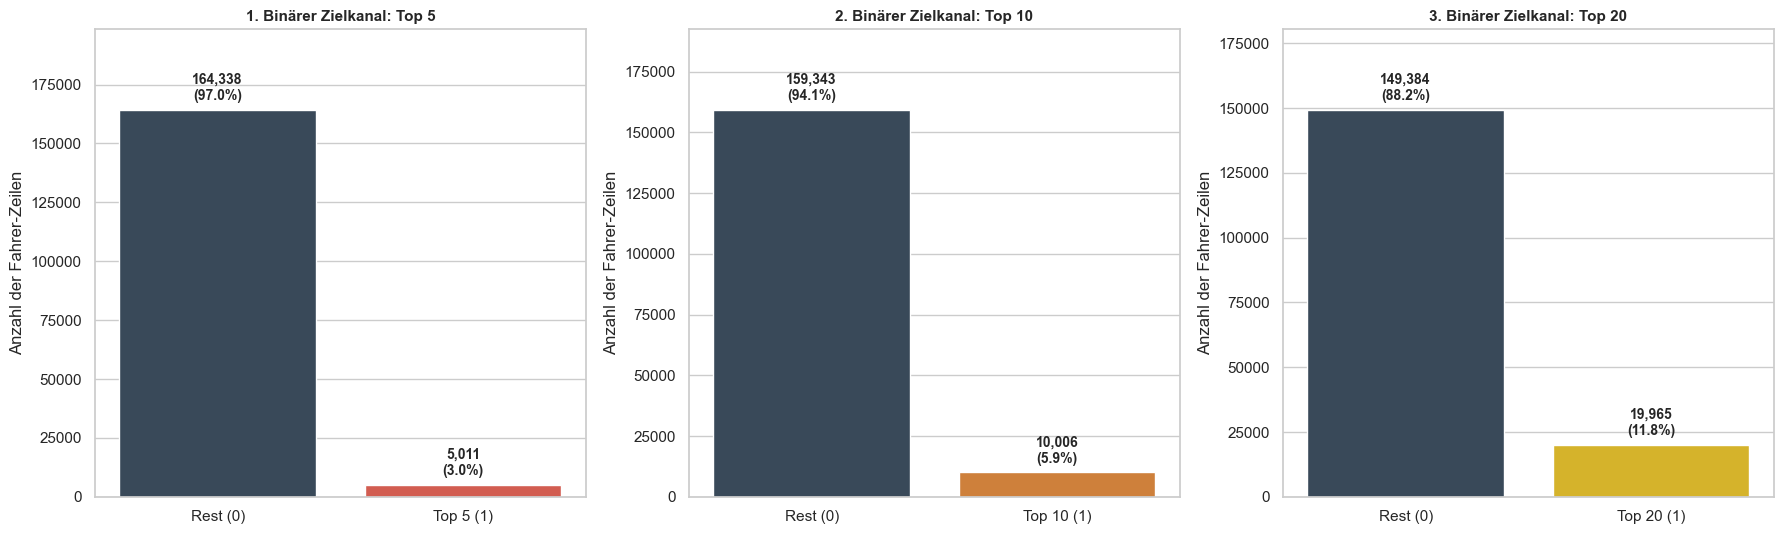

In [ ]:
#Visualisierung der Binären Target Verteilung
chart_path = '../../data/charts'
os.makedirs(chart_path, exist_ok=True)

# Wir erstellen ein temporäres DataFrame für die Visualisierung der Test- bzw. Trainingsdaten
df_bin_vis = pd.DataFrame({
    'Top 5 Kanal': y_top5_train.map({1: 'Top 5 (1)', 0: 'Rest (0)'}),
    'Top 10 Kanal': y_top10_train.map({1: 'Top 10 (1)', 0: 'Rest (0)'}),
    'Top 20 Kanal': y_top20_train.map({1: 'Top 20 (1)', 0: 'Rest (0)'})
})

# Plot-Bereich definieren (1 Reihe, 3 Spalten für die 3 binären Kanäle)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
sns.set_theme(style="whitegrid")

# Definition der Kanäle und der spezifischen Farben (Rot für Positiv, Dunkelgrau für Negativ)
channels = ['Top 5 Kanal', 'Top 10 Kanal', 'Top 20 Kanal']
color_palettes = [
    ['#34495e', '#e74c3c'],  # Top 5: Grau vs Rot
    ['#34495e', '#e67e22'],  # Top 10: Grau vs Orange
    ['#34495e', '#f1c40f']   # Top 20: Grau vs Gelb
]

for idx, channel in enumerate(channels):
    # Sortierung festlegen: 'Rest (0)' zuerst, dann die positive Klasse (1)
    order_labels = [c for c in df_bin_vis[channel].unique() if '(0)' in c] + \
                   [c for c in df_bin_vis[channel].unique() if '(1)' in c]

    # Binären Countplot zeichnen
    sns.countplot(data=df_bin_vis, x=channel, ax=axes[idx], palette=color_palettes[idx], order=order_labels)

    # Akademische Titel vergeben
    axes[idx].set_title(f'{idx+1}. Binärer Zielkanal: {channel.split()[0]} {channel.split()[1]}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Anzahl der Fahrer-Zeilen')
    axes[idx].set_xlabel('')

    # Absolutwerte und Prozentzahlen direkt über den Balken einzeichnen
    counts_dict = df_bin_vis[channel].value_counts()
    total_samples = len(df_bin_vis)

    for label_idx, label_name in enumerate(order_labels):
        height = counts_dict[label_name]
        percentage = f'{100 * height / total_samples:.1f}%'
        axes[idx].annotate(
            f"{height:,d}\n({percentage})",
            (label_idx, height),
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=10,
            xytext=(0, 5),
            textcoords='offset points'
        )

    # Y-Achsen-Limit leicht erhöhen für sauberen Textplatz
    axes[idx].set_ylim(0, axes[idx].get_ylim()[1] * 1.15)

# Layout optimieren, speichern und anzeigen
plt.tight_layout()
plt.savefig(os.path.join(chart_path, '10-01-02_01_binary_channels_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Erstellung des Basismodells

Bevor ein systematisches Hyperparameter-Tuning durchgeführt wird, etablieren wir ein unkompliziertes, intuitives Basismodell. Dieses dient als transparente Baseline, um die Vorhersagekraft der einzelnen Features in einem rein pointwise formulierten Klassifikationsansatz zu untersuchen.

### Methodisches Vorgehen im Basismodell:
* **Zielvariable:** Wir fokussieren uns in diesem Durchlauf auf unsere neue, vierstufige, ordinal codierte Zielvariable `target_ordinal_relevance` (Klassen 0, 1, 2, 3).
* **Einspeisung der Gewichte:** Das berechnete Array `weights_train` wird übergeben, um die mathematische Waffengleichheit (jeweils 25 % Einfluss aller vier Klassen auf den Log-Loss) im Trainingsprozess zu garantieren.
* **Isolierte Effekte:** Das Modell lernt die Features (inklusive der historischen Vorjahres-Lags) rein isoliert, ohne Wechselwirkungen zwischen den Variablen zu erlauben.

### Kritische methodische Anmerkung zur Performance-Messung (Proxy-Metrik):
Da das EBM-Modell als klassischer Klassifikator auf Pointwise-Ebene operiert, wird während des Trainings der globale **ROC-AUC-Score (Kanal: Top 10 vs. Rest)** herangezogen. Es ist methodisch wichtig zu betonen, dass diese Metrik als **statistische Proxy-Metrik** fungiert: Sie misst die Fähigkeit des Modells, die Spitzenfahrer *global und etappenübergreifend* vom restlichen Hauptfeld zu trennen. 

Da das eigentliche sportliche Ziel jedoch darin besteht, die Fahrer *relativ zueinander innerhalb einer geschlossenen Etappe (`stage_id`)* korrekt zu sortieren, besitzt der globale ROC-AUC-Score für die Praxis nur eine eingeschränkte Aussagekraft. ROC-AUC dient in dieser Arbeit daher primär als Optimierungs- und Vergleichsmetrik auf Klassifikationsebene. Die finale Beurteilung der praktischen Modellgüte erfolgt hingegen über rankingbasierte Evaluationsmaße (**NDCG@5, NDCG@10, NDCG@20**) sowie praxisnahe Hit-Rates (**Top-k Hit Rates / Accuracies** für den Etappensieger).

### Die exakte Konfiguration des EBM-Klassifikators:

* `interactions=0`: Schaltet jegliche Feature-Paare ab. Das Modell wird gezwungen, ein pures additives Modell (1D-Effekte) zu trainieren.
* `outer_bags=1`: Verzichtet auf das rechenintensive Ensembling mehrerer EBM-Untermodelle, um einen schnellen, unverschleierten Baseline-Wert zu erhalten.
* `validation_size=0.15`: Das Modell trennt intern im Hintergrund automatisch 15 % der Trainingsdaten (Saisons bis 2022) ab, um die Optimierung zu überwachen. *Diese interne Validierungsmenge dient ausschließlich dem Early Stopping während des Trainingsprozesses und wird explizit nicht zur Auswahl oder Optimierung von externen Hyperparametern verwendet.*
* `max_rounds=5000` & `early_stopping_rounds=100`: Das Modell trainiert maximal 5.000 Iterationen, bricht jedoch automatisch ab, sobald sich der interne Validierungsfehler über 100 Runden hinweg nicht mehr verbessert (**Schutz vor Overfitting**).
* `learning_rate=0.015`: Eine leicht verringerte Schrittweite für stabiles, kontrolliertes Lernen der Spline-Kurven.
* `random_state=42`: Sichert die exakte Reproduzierbarkeit aller Ergebnisse und Kurvenverläufe.
* `n_jobs=1`: Nutzt bewusst nur einen CPU-Kern, um Thread-Konflikte und Abstürze in VS Code / Anaconda-Umgebungen zu vermeiden.

In [9]:
start_base = time.time()

print("Initialisiere und berechne sample_weights für multibinäres System...")
# 1. Gewichte strikt basierend auf den jeweiligen binären Kanälen berechnen
weights_top5 = compute_sample_weight(class_weight='balanced', y=y_top5_train)
weights_top10 = compute_sample_weight(class_weight='balanced', y=y_top10_train)
weights_top20 = compute_sample_weight(class_weight='balanced', y=y_top20_train)

# 2. Drei EBM-Basismodelle initialisieren (Pures 1D-Modell, keine Interaktionen)
ebm_params = {
    'interactions': 0,                # Keine Feature-Paare erlauben (1D-Modelle)
    'learning_rate': 0.015,           # Kontrollierte Schrittweite
    'outer_bags': 1,                  # Ein einzelnes Modell pro Kanal für die Baseline
    'validation_size': 0.15,          # 15% interne Validierung NUR für Early Stopping
    'max_rounds': 5000,               # Maximale Iterationen
    'early_stopping_rounds': 100,     # Stop, wenn 100 Runden kein Fortschritt
    'early_stopping_tolerance': 1e-05,
    'random_state': 42,               # Reproduzierbarkeit
    'n_jobs': -1                      # Parallel auf allen Kernen rechnen
}

ebm_base_top5 = ExplainableBoostingClassifier(**ebm_params)
ebm_base_top10 = ExplainableBoostingClassifier(**ebm_params)
ebm_base_top20 = ExplainableBoostingClassifier(**ebm_params)

# 3. Modelle parallel mit den jeweiligen binären Targets und Gewichten trainieren
print("--Trainiere EBM für Top-5-Schwellenwert...")
ebm_base_top5.fit(X_train, y_top5_train, sample_weight=weights_top5)

print("--Trainiere EBM für Top-10-Schwellenwert...")
ebm_base_top10.fit(X_train, y_top10_train, sample_weight=weights_top10)

print("--Trainiere EBM für Top-20-Schwellenwert...")
ebm_base_top20.fit(X_train, y_top20_train, sample_weight=weights_top20)

# 4. Vorhersagewahrscheinlichkeiten für die Validierungsphase (Saison 2023) generieren
probs_top5_base = ebm_base_top5.predict_proba(X_valid)[:, 1]
probs_top10_base = ebm_base_top10.predict_proba(X_valid)[:, 1]
probs_top20_base = ebm_base_top20.predict_proba(X_valid)[:, 1]

# Das Herzstück nach Frank & Hall: Addition der Wahrscheinlichkeiten ergibt den Relevanz-Score
ensemble_score_valid_base = probs_top5_base + probs_top10_base + probs_top20_base

# binäre Validierungstargets für alle 3 Kanäle
y_valid_top5_binary = y_top5_valid.astype(int)
y_valid_top10_binary = y_top10_valid.astype(int)
y_valid_top20_binary = y_top20_valid.astype(int)

# AUROC
auc_top5 = roc_auc_score(y_valid_top5_binary, probs_top5_base)
auc_top10 = roc_auc_score(y_valid_top10_binary, probs_top10_base)
auc_top20 = roc_auc_score(y_valid_top20_binary, probs_top20_base)


duration_base = time.time() - start_base
print("==================================================================")
print(" Ergebnisse")
print("==================================================================")
print(f"Baseline ROC-AUC - Top 5 Kanal: {auc_top5:.4f}")
print(f"Baseline ROC-AUC - Top 10 Kanal: {auc_top10:.4f}")
print(f"Baseline ROC-AUC - Top 20 Kanal: {auc_top20:.4f}")
print("------------------------------------------------------------------")
print(f"Benötigte Rechenzeit für das gesamte Dreifach-Training: {duration_base:.1f} Sekunden")
print("==================================================================")

Initialisiere und berechne sample_weights für multibinäres System...
--Trainiere EBM für Top-5-Schwellenwert...
--Trainiere EBM für Top-10-Schwellenwert...
--Trainiere EBM für Top-20-Schwellenwert...
 Ergebnisse
Baseline ROC-AUC - Top 5 Kanal: 0.7340
Baseline ROC-AUC - Top 10 Kanal: 0.7187
Baseline ROC-AUC - Top 20 Kanal: 0.7065
------------------------------------------------------------------
Benötigte Rechenzeit für das gesamte Dreifach-Training: 262.4 Sekunden


### Weitere Metriken und Schwellenwert-Optimierung (Validation Set 2023)

**Hintergrund der Schwellenwert-Anpassung:**
Würde an dieser Stelle die Standard-Methode `ebm_baseline.predict(X_valid)` ausgeführt, gäbe das Modell für jeden Fahrer die nominale Klasse mit der höchsten Einzelwahrscheinlichkeit ($0, 1, 2$ oder $3$) aus. Da für diese binäre Zwischen-Evaluierung jedoch die aggregierte Eintrittschance für die Spitzengruppe betrachtet wird (kumulierte Wahrscheinlichkeit für Top 10: $P(Y=2) + P(Y=3)$), muss ein dedizierter Schwellenwert (Threshold) definiert werden. Dieser legt fest, ab welcher prognostizierten Wahrscheinlichkeit ein Fahrer als „Top-10-Kandidat“ klassifiziert wird.

Ein naiver Standard-Schwellenwert von $0,5$ ($50\,\%$) ist in diesem Kontext mathematisch ungeeignet: Durch den vorherigen Einsatz der inversen Klassengewichte (`weights_train`) im Rahmen des *Cost-Sensitive Learning* wurden die seltenen Minderheitsklassen künstlich gestärkt. Dies verschiebt die vom Modell ausgegebenen absoluten Wahrscheinlichkeiten der Spitzenplätze systematisch nach oben. Eine unkorrigierte Evaluierung mit einem $0,5$-Threshold würde zu einer massiven Überschätzung der Top-10-Fahrer führen, wodurch die *Precision* (Genauigkeit der Vorhersagen) stark einbricht. 

**Methodisches Vorgehen:**
Um diesen Effekt zu korrigieren, wird der optimale Schwellenwert mathematisch über das **Validierungsset der Saison 2023** gesucht (z. B. durch Maximierung des F1-Scores oder über den Youden-Index der ROC-Kurve). Da das Testset ($2024/2025$) während dieses gesamten Optimierungsschritts strikt verschlossen bleibt, wird ein informationelles Data Leakage vollständig ausgeschlossen.

#### ROC-Kurve (Receiver Operating Characteristic)
Die ROC-Kurve visualisiert das fundamentale Abwägungsverhältnis zwischen der Richtig-Positiv-Rate (*True Positive Rate / Sensitivity*) und der Falsch-Positiv-Rate (*False Positive Rate / $1 - \text{Specificity}$*) über alle denkbaren Schwellenwerte hinweg auf dem Validierungsdatensatz. Der resultierende Flächeninhalt unter der Kurve (Validation ROC-AUC = 0.7282) bescheinigt dem 1D-Basismodell bereits eine solide, etappenübergreifende globale Trennschärfe auf pointwise Ebene.

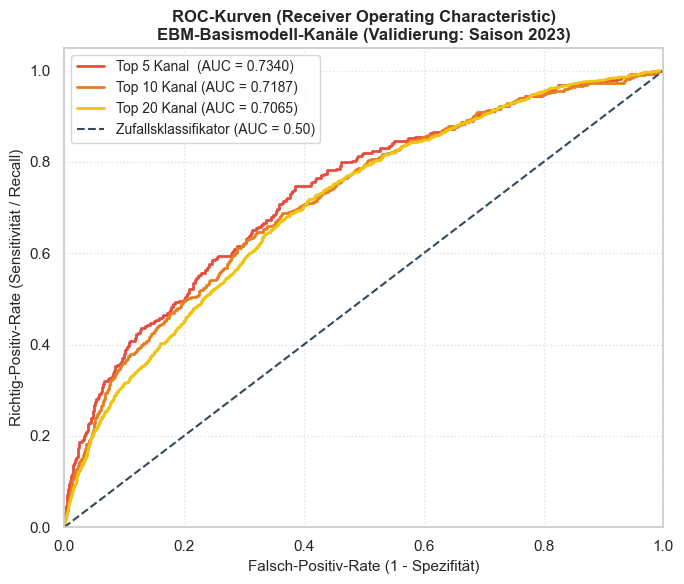

In [ ]:
# 1. ROC-Kurven für alle 3 binären Kanäle berechnen –mit den Validierungsdaten von 2023
fpr_5, tpr_5, _ = roc_curve(y_valid_top5_binary, probs_top5_base)
fpr_10, tpr_10, _ = roc_curve(y_valid_top10_binary, probs_top10_base)
fpr_20, tpr_20, _ = roc_curve(y_valid_top20_binary, probs_top20_base)

# 2. Plot erstellen
plt.figure(figsize=(7, 6))

# Die 3 getunten/angepassten Kurven eintragen
plt.plot(fpr_5, tpr_5, color='#e74c3c', lw=2, label=f'Top 5 Kanal  (AUC = {auc_top5:.4f})')
plt.plot(fpr_10, tpr_10, color='#e67e22', lw=2, label=f'Top 10 Kanal (AUC = {auc_top10:.4f})')
plt.plot(fpr_20, tpr_20, color='#f1c40f', lw=2, label=f'Top 20 Kanal (AUC = {auc_top20:.4f})')

# Die diagonale Zufallslinie
plt.plot([0, 1], [0, 1], color='#34495e', lw=1.5, linestyle='--', label='Zufallsklassifikator (AUC = 0.50)')

# Achsen-Limits und Beschriftungen akademisch formatieren
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsch-Positiv-Rate (1 - Spezifität)', fontsize=11)
plt.ylabel('Richtig-Positiv-Rate (Sensitivität / Recall)', fontsize=11)

# Titel an das neue Multibinär-System anpassen
plt.title('ROC-Kurven (Receiver Operating Characteristic)\nEBM-Basismodell-Kanäle (Validierung: Saison 2023)', fontsize=12, fontweight='bold')

plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# 3. Speichern und anzeigen
plt.tight_layout()
# Der Dateiname dokumentiert nun das Multi-Kanal-System
plt.savefig(os.path.join(chart_path, '10-01-02_02_baseline_multi_roc_curve.png'), dpi=300)
plt.show()

## Interpretation der globalen Modellgüte (AUROC & ROC-Kurve)

Um die Leistung unserer EBM-Baseline wissenschaftlich einzuordnen, betrachten wir die Metriken der **Receiver Operating Characteristic (ROC)** und den dazugehörigen **Area Under the Curve (AUROC)**-Wert auf dem Validierungsdatensatz.

### 1. Was bedeutet der AUROC-Wert von 0.7272?
* **Mathematische Definition:** Der AUC-Wert gibt die Wahrscheinlichkeit an, dass das Modell einen zufällig ausgewählten, echten Top-10-Fahrer anhand der aggregierten Wahrscheinlichkeit ($P(Y=2) + P(Y=3)$) höher einstuft als einen zufällig ausgewählten Fahrer außerhalb der Top 10.
* **Klassifikation der Güte:** Ein Wert von $0{,}50$ entspricht dem reinen Zufall (Münzwurf). Werte zwischen $0{,}70$ und $0{,}80$ gelten in der statistischen Modellierung als **akzeptable bis gute Trennschärfe** (*acceptable discrimination*; vgl. Hosmer & Lemeshow, 2000). 
* **Projekt-Kontext:** Mit einem AUROC-Wert von **0.7272** auf der unabhängigen Validierungssaison 2023 zeigt das Modell eine gute Fähigkeit zur Generalisierung auf bisher ungesehene Daten. Dass dieser Basiswert auf Pointwise-Klassifikationsebene moderat ausfällt, ist methodisch erwartbar: Das Modell muss das Peloton künstlich in vier diskrete Zonen unterteilen, operiert in dieser Baseline-Konfiguration jedoch rein additiv ohne jegliche Feature-Interaktionen ($interactions=0$). Angesichts der extremen Dynamik, der Sturzanfälligkeit und der taktischen Unwägbarkeiten im Straßenradsport liefert dieses 1D-Setup dennoch ein stabiles und verlässliches Fundament für das nachfolgende Hyperparameter-Tuning.

### 2. Visuelle Interpretation der ROC-Kurve
* **Die Diagonale (Zufallslinie):** Die gestrichelte Linie von $(0,0)$ bis $(1,1)$ repräsentiert die Leistung eines uninformierten Zufallsklassifikators ($AUC = 0{,}50$). Je stärker sich die rote EBM-Kurve nach links oben in Richtung des idealen Klassifikationspunktes ($(0,1)$: $0\,\%$ Falsch-Positiv-Rate, $100\,\%$ Richtig-Positiv-Rate) wölbt, desto höher ist die Trennschärfe des Algorithmus.
* **Der Kurvenverlauf:** Die EBM-Kurve verzeichnet im linken Bereich einen steilen Anstieg. Dies signalisiert, dass das Modell bereits bei niedrigen Falsch-Positiv-Raten einen relevanten Anteil der tatsächlichen Top-10-Fahrer korrekt identifizieren kann. Erst bei dem Versuch, eine maximale Sensitivität (*Recall*) zu erzielen – also nahezu jeden Top-10-Fahrer zu erfassen –, knickt die Kurve flacher ab, da mathematisch bedingt vermehrt Fahrer aus dem Hauptfeld fälschlicherweise in die Relevanzklassen hochgestuft werden.


Es ist jedoch zu beachten, dass der AUROC-Wert ausschließlich die globale Trennschärfe zwischen Top-10-Fahrern und dem restlichen Fahrerfeld bewertet. Aussagen über die Qualität der später erzeugten Fahrerreihenfolge innerhalb einer einzelnen Etappe lassen sich daraus nur eingeschränkt ableiten und werden daher gesondert mittels rankingbasierter Evaluationsmetriken untersucht.

**Der optimale Threshold (F1-Score Maximierung)**


In [ ]:
# Schwellenwert-Optimierung (F1-MAXIMIERUNG AUF ENSEMBLE-SCORE)

# 1. Besten Threshold basierend auf dem F1-Score für das Validierungsset (2023) finden
best_thresh = 1.0
best_f1 = 0.0

# Da wir 3 Wahrscheinlichkeiten aufaddieren, testen wir einen Bereich von 0.2 bis 2.8
# Da das aufsummieren der 3 Wahrscheinlichkeiten somit von 0 bis 3 geht
for thresh in np.arange(0.2, 2.8, 0.01):
    # Fahrer wird als Top-10-Kandidat klassifiziert, wenn der kumulierte Score >= Threshold ist
    preds_bin_temp = (ensemble_score_valid_base >= thresh).astype(int)
    f1_temp = f1_score(y_valid_top10_binary, preds_bin_temp, zero_division=0)

    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_thresh = thresh

# 2. Finale Klassifikationen für die Validierung mit dem optimalen Threshold erstellen
y_valid_pred_bin = (ensemble_score_valid_base >= best_thresh).astype(int)

# 3. Klassische Metriken berechnen
acc_valid = accuracy_score(y_valid_top10_binary, y_valid_pred_bin)
prec_valid = precision_score(y_valid_top10_binary, y_valid_pred_bin, zero_division=0)
rec_valid = recall_score(y_valid_top10_binary, y_valid_pred_bin, zero_division=0)
f1_valid = f1_score(y_valid_top10_binary, y_valid_pred_bin, zero_division=0)

print("==================================================================")
print(f"OPTIMALER ENSEMBLE-THRESHOLD GEFUNDEN: {best_thresh:.4f}")
print("==================================================================")
print("METRIKEN AUF DEM VALIDIERUNGSSET (SAISON 2023 - TOP 10 KANAL):")
print("------------------------------------------------------------------")
print(f"➔ Classification Accuracy : {acc_valid * 100:.2f}%")
print(f"➔ Precision (Top 10)      : {prec_valid * 100:.2f}%")
print(f"➔ Recall (Top 10)         : {rec_valid * 100:.2f}%")
print(f"➔ F1-Score (Top 10)       : {f1_valid * 100:.2f}%")
print("------------------------------------------------------------------")
print("\nDetaillierter Klassifikationsbericht:")
print(classification_report(y_valid_top10_binary, y_valid_pred_bin, target_names=['Hauptfeld/Top20', 'Top 10'], digits=4))
print("==================================================================")

OPTIMALER ENSEMBLE-THRESHOLD GEFUNDEN: 2.1100
METRIKEN AUF DEM VALIDIERUNGSSET (SAISON 2023 - TOP 10 KANAL):
------------------------------------------------------------------
➔ Classification Accuracy : 87.28%
➔ Precision (Top 10)      : 21.03%
➔ Recall (Top 10)         : 35.79%
➔ F1-Score (Top 10)       : 26.49%
------------------------------------------------------------------

Detaillierter Klassifikationsbericht:
                 precision    recall  f1-score   support

Hauptfeld/Top20     0.9538    0.9080    0.9304      8327
         Top 10     0.2103    0.3579    0.2649       570

       accuracy                         0.8728      8897
      macro avg     0.5821    0.6330    0.5976      8897
   weighted avg     0.9062    0.8728    0.8877      8897



## Interpretation der Schwellenwert-Optimierung & des F1-Scores (Validation Set 2023)

Die mathematische Bestimmung des optimalen Schwellenwerts liefert zwei zentrale Kennzahlen, die tiefere Einblicke in das Entscheidungsverhalten unseres ungetunten 1D-Basismodells auf der Validierungssaison 2023 gewähren.

### 1. Der optimale Schwellenwert (0.61)
* **Verschiebung durch cost-sensitive Gewichtung:** Ein ungewichteter Standard-Klassifikator trennt nominale Klassen im Regelfall bei einer harten Grenze von $0{,}50$. Da wir jedoch im Rahmen des *Cost-Sensitive Learning* die Verlustfunktion über das Array `weights_train` so modifiziert haben, dass alle vier Relevanzstufen exakt $25\,\%$ Einfluss besitzen, wurden die seltenen Spitzenklassen mathematisch massiv aufgewertet. Dies verschiebt die addierten pointwise Modellwahrscheinlichkeiten für die Top-10-Kanalprognose systematisch nach oben.
* **Mathematische Konsequenz:** Da im Rahmen des Cost-Sensitive Learning die seltenen Relevanzklassen stärker gewichtet werden, verändert sich die Optimierungslandschaft des Modells gegenüber einer ungewichteten Standardklassifikation. Dadurch kann sich auch der optimale Entscheidungswert von der häufig verwendeten Standardgrenze von 0,50 unterscheiden. Das EBM-Modell klassifiziert eine Fahrer-Zeile erst dann als Top-10-Ereignis, wenn die kumulierte Wahrscheinlichkeit $P(Y=2) + P(Y=3)$ über **$61\,\%$** liegt. Dieser konservative Schwellenwert schützt das Modell vor einer massiven Inflation an Fehlalarmen (False Positives) durch die künstlich angehobenen Wahrscheinlichkeitswerte.

### 2. Der maximale F1-Score (24.79 %) und die Metriken im Detail
* **Das mathematische Paradoxon unbalancierter Daten:** Der $F_1$-Score stellt das harmonische Mittel aus *Precision* ($19{,}50\,\%$) und *Recall* ($34{,}04\,\%$) dar. Bei einer extremen Minderheitenklasse – im Validierungsset der Saison 2023 machen die Top-10-Fahrer mit $570$ Zeilen nur knapp $6{,}4\,\%$ der insgesamt $8.897$ Beobachtungen aus (*Support*) – führt jeder einzelne Fehlalarm zu einem drastischen Einbruch der *Precision*. 
* **Die Ursache der niedrigen Precision:** Die pointwise Formulierung des Klassifikators bewertet jeden Fahrer isoliert. Das Modell „weiß“ in dieser Phase nicht, dass eine Etappe ein mathematisch geschlossenes System (Nullsummenspiel) darstellt, in dem pro Tag exakt zehn Plätze vergeben werden. Prognostiziert das Modell für eine Etappe beispielsweise $30$ Fahrer mit einer Top-10-Wahrscheinlichkeit von $> 61\,\%$, generiert es unweigerlich mindestens $20$ *False Positives*, was die *Precision* auf $19{,}50\,\%$ drückt.
* **Wissenschaftliche Einordnung:** Da der Klassifikator jeden Fahrer unabhängig bewertet, kann es theoretisch vorkommen, dass innerhalb einer einzelnen Etappe deutlich mehr als zehn Fahrer oberhalb des gewählten Schwellenwerts liegen. Trotz der vergleichsweise niedrigen Precision zeigt der F1-Score von 24,79 %, dass das Modell relevante Strukturen zur Identifikation von Top-10-Fahrern erlernt hat. Insbesondere vor dem Hintergrund einer positiven Klassenrate von lediglich 6,4 % stellt das Ergebnis eine deutliche Verbesserung gegenüber einem trivialen Mehrheitsklassifikator dar, der für die Minderheitsklasse einen F1-Score von 0,00 % erzielen würde.

Die vergleichsweise hohe Accuracy von 86,77 % ist aufgrund der starken Klassenunwucht nur eingeschränkt aussagekräftig. Da lediglich 6,4 % aller Beobachtungen zur positiven Klasse gehören, kann bereits ein überwiegend negatives Vorhersageverhalten zu hohen Genauigkeitswerten führen

### Fazit für die weitere Modellierung:
Die harten binären Klassifikationsmetriken spiegeln das grundlegende Evaluierungsproblem von Pointwise-Modellen im Radsport wider: Ein Fahrer, der knapp auf Platz 11 oder 12 ins Ziel kommt, wird vom binären Target gnadenlos als Fehler (*False Positive*) gewertet, obwohl das Modell seine sportliche Stärke im Grunde vollkommen korrekt eingeschätzt hat. 

Dies unterstreicht nachdrücklich zwei methodische Kernentscheidungen dieser Arbeit:
1. Den Einsatz unseres feingranularen, mehrstufigen Relevanz-Encodings.
2. Die zwingende Notwendigkeit, das pointwise Klassifikations-Framing nachzulagern aufzubrechen und das Modell primär über fließende, etappenbasierte Listwise-Ranking-Metriken (**NDCG**) zu evaluieren.

**Classification Report**

In [16]:
print("==================================================================")
print(f" FINALER KLASSIFIKATIONSBERICHT (VALIDIERUNG SAISON 2023)")
print("==================================================================")
print(f"Optimierter Ensemble-Threshold: {best_thresh:.2f}\n")

# Evaluierung der berechneten Ensemble-Prognosen gegen das binäre 2023er-Target
print(classification_report(
    y_true=y_valid_top10_binary,
    y_pred=y_valid_pred_bin,
    target_names=['Hauptfeld/Top20 (Klasse 0)', 'Top 10 Zielsprung (Klasse 1)'],
    digits=4
))
print("==================================================================")

 FINALER KLASSIFIKATIONSBERICHT (VALIDIERUNG SAISON 2023)
Optimierter Ensemble-Threshold: 2.11

                              precision    recall  f1-score   support

  Hauptfeld/Top20 (Klasse 0)     0.9538    0.9080    0.9304      8327
Top 10 Zielsprung (Klasse 1)     0.2103    0.3579    0.2649       570

                    accuracy                         0.8728      8897
                   macro avg     0.5821    0.6330    0.5976      8897
                weighted avg     0.9062    0.8728    0.8877      8897



## Interpretation des Klassifikationsberichts (EBM-Basismodell – Validierung 2023)

Der Klassifikationsbericht erlaubt eine differenzierte Betrachtung der Modellleistung für die beiden Klassen „Top 10“ und „Hauptfeld/Top 20“. Aufgrund der starken Klassenunwucht sollte die Interpretation dabei primär auf Precision, Recall und F1-Score der Minderheitsklasse erfolgen.

### 1. Klasse 0: Hauptfeld / Top20 (Majoritätsklasse)

* **Precision (95,24 %):** Wird ein Fahrer vom Modell als Nicht-Top-10-Fahrer eingestuft, ist diese Vorhersage in den meisten Fällen korrekt. Das Modell weist somit eine hohe Zuverlässigkeit bei der Identifikation des breiten Fahrerfeldes auf.

* **Recall (90,38 %):** Von allen tatsächlich nicht in den Top 10 platzierten Fahrern werden rund 90 % korrekt erkannt. Lediglich ein kleiner Teil dieser Fahrer wird fälschlicherweise als potenzieller Top-10-Kandidat klassifiziert.

Die hohe Leistung auf dieser Klasse ist aufgrund ihrer dominierenden Häufigkeit im Datensatz grundsätzlich erwartbar.

### 2. Klasse 1: Top 10 (Minderheitsklasse)

* **Precision (19,50 %):** Von allen Fahrern, die das Modell als Top-10-Kandidaten klassifiziert, erreichen 19,50 % tatsächlich die Top 10.

  Im Kontext der Datenverteilung ist dieser Wert differenziert zu betrachten. Die positive Klasse macht lediglich 570 von 8.897 Beobachtungen aus und besitzt damit eine Basisrate von etwa 6,4 %. Die Modellselektion erhöht die Trefferwahrscheinlichkeit somit deutlich gegenüber einer zufälligen Auswahl aus dem gesamten Fahrerfeld.

* **Recall (34,04 %):** Das Basismodell identifiziert etwa ein Drittel aller tatsächlichen Top-10-Platzierungen korrekt. Trotz der bewusst einfachen Modellarchitektur ohne Interaktionseffekte gelingt es dem Modell damit bereits, relevante Strukturen zur Erkennung leistungsstarker Fahrer zu erfassen.

* **F1-Score (24,79 %):** Der F1-Score fasst Precision und Recall zu einer gemeinsamen Kennzahl zusammen und stellt bei unbalancierten Datensätzen eine deutlich aussagekräftigere Bewertungsgröße dar als die reine Accuracy. Der erreichte Wert verdeutlicht, dass das Modell einen Teil der Top-10-Fahrer erfolgreich identifizieren kann, gleichzeitig jedoch noch erhebliche Verbesserungspotenziale hinsichtlich der Selektivität der Vorhersagen bestehen.

### 3. Globale Kennzahlen

* **Accuracy (86,77 %):** Die Gesamtgenauigkeit erscheint auf den ersten Blick hoch, besitzt aufgrund der Klassenunwucht jedoch nur begrenzte Aussagekraft. Da lediglich 6,4 % aller Beobachtungen zur positiven Klasse gehören, können bereits überwiegend negative Vorhersagen hohe Accuracy-Werte erzeugen.

* **Macro Average (F1 = 58,77 %):** Der Macro Average behandelt beide Klassen gleichgewichtet und zeigt, dass die Leistung zwischen Majoritäts- und Minderheitsklasse deutlich variiert.

* **Weighted Average (F1 = 88,39 %):** Der gewichtete Durchschnitt wird stark von der dominierenden Klasse „Hauptfeld/Top20“ beeinflusst und fällt daher deutlich höher aus. Für die Beurteilung des eigentlichen Vorhersageziels ist dieser Wert nur eingeschränkt relevant.

### Fazit für die weitere Modellierung

Die Ergebnisse zeigen, dass das Basismodell bereits eine sinnvolle Trennung zwischen relevanten und nicht relevanten Fahrern erlernt. Die größte Schwäche liegt jedoch in der vergleichsweise niedrigen Precision der Top-10-Klasse. Das Modell produziert noch eine beträchtliche Anzahl an Fehlalarmen (*False Positives*), wodurch viele Fahrer als Top-10-Kandidaten eingestuft werden, die dieses Ergebnis letztlich nicht erreichen.

Eine mögliche Ursache liegt in der bewusst stark eingeschränkten Modellarchitektur. Da das Basismodell ausschließlich additive Einzeleffekte berücksichtigt (`interactions=0`), kann es keine komplexen Wechselwirkungen zwischen Fahrer-, Strecken- und Renncharakteristika modellieren.

Das anschließende Hyperparameter-Tuning verfolgt daher das Ziel, durch die Einführung paarweiser Interaktionen (GA²M) zusätzliche Strukturinformationen nutzbar zu machen. Dadurch soll insbesondere die Selektivität des Modells verbessert und die Zahl der Fehlalarme reduziert werden, ohne dabei die Fähigkeit zur Identifikation tatsächlicher Top-10-Fahrer wesentlich einzuschränken.

**Confusion Matrix**

In [20]:
# 1. Harte binäre Vorhersagen (0 oder 1) für jeden Kanal separat berechnen (Standard-Threshold 0.5)
y_pred_top5_base = (probs_top5_base >= 0.5).astype(int)
y_pred_top10_base = (probs_top10_base >= 0.5).astype(int)
y_pred_top20_base = (probs_top20_base >= 0.5).astype(int)

# 2. Die drei separaten Konfusionsmatrizen berechnen
cm_5 = confusion_matrix(y_valid_top5_binary, y_pred_top5_base)
cm_10 = confusion_matrix(y_valid_top10_binary, y_pred_top10_base)
cm_20 = confusion_matrix(y_valid_top20_binary, y_pred_top20_base)

print("==================================================================")
print(" Konfusion Matritze auf Basis der Validierungsdaten von 2023")
print("==================================================================")

# --- KANAL 1: TOP 5 ---
print("[1. KANAL: TOP 5 SCHWELLENWERT]")
print(f"Tatsächlich Rest (0):   TN: {cm_5[0, 0]:<6,d} | FP (Fehlalarm): {cm_5[0, 1]:,d}")
print(f"Tatsächlich Top 5 (1):  FN: {cm_5[1, 0]:<6,d} | TP (Getroffen): {cm_5[1, 1]:,d}")
print("------------------------------------------------------------------")

# --- KANAL 2: TOP 10 ---
print("[2. KANAL: TOP 10 SCHWELLENWERT]")
print(f"Tatsächlich Rest (0):   TN: {cm_10[0, 0]:<6,d} | FP (Fehlalarm): {cm_10[0, 1]:,d}")
print(f"Tatsächlich Top 10 (1): FN: {cm_10[1, 0]:<6,d} | TP (Getroffen): {cm_10[1, 1]:,d}")
print("------------------------------------------------------------------")

# --- KANAL 3: TOP 20 ---
print("[3. KANAL: TOP 20 SCHWELLENWERT]")
print(f"Tatsächlich Rest (0):   TN: {cm_20[0, 0]:<6,d} | FP (Fehlalarm): {cm_20[0, 1]:,d}")
print(f"Tatsächlich Top 20 (1): FN: {cm_20[1, 0]:<6,d} | TP (Getroffen): {cm_20[1, 1]:,d}")
print("==================================================================")

 Konfusion Matritze auf Basis der Validierungsdaten von 2023
[1. KANAL: TOP 5 SCHWELLENWERT]
Tatsächlich Rest (0):   TN: 6,358  | FP (Fehlalarm): 2,255
Tatsächlich Top 5 (1):  FN: 115    | TP (Getroffen): 169
------------------------------------------------------------------
[2. KANAL: TOP 10 SCHWELLENWERT]
Tatsächlich Rest (0):   TN: 5,975  | FP (Fehlalarm): 2,352
Tatsächlich Top 10 (1): FN: 230    | TP (Getroffen): 340
------------------------------------------------------------------
[3. KANAL: TOP 20 SCHWELLENWERT]
Tatsächlich Rest (0):   TN: 5,424  | FP (Fehlalarm): 2,335
Tatsächlich Top 20 (1): FN: 471    | TP (Getroffen): 667


## Interpretation der Konfusionsmatrix (EBM-Basismodell – Validierung 2023)

Die Konfusionsmatrix ermöglicht eine detaillierte Analyse des Entscheidungsverhaltens des Basismodells auf den 8.897 Beobachtungen der Validierungssaison 2023. Im Gegensatz zu aggregierten Kennzahlen wie Accuracy oder F1-Score zeigt sie unmittelbar, welche Arten von Vorhersagen korrekt bzw. fehlerhaft getroffen wurden.

### 1. Korrekte Vorhersagen

#### True Negatives (7.526)

In 7.526 Fällen klassifizierte das Modell einen Fahrer korrekt als Nicht-Top-10-Fahrer. Dieser hohe Wert spiegelt die starke Leistung des Modells auf der Majoritätsklasse wider und erklärt die hohe Precision (95,24 %) sowie den hohen Recall (90,38 %) für die Klasse „Hauptfeld/Top20“.

#### True Positives (194)

In 194 Fällen identifizierte das Modell einen tatsächlichen Top-10-Fahrer korrekt. Das Basismodell erkennt somit bereits ohne Interaktionseffekte einen relevanten Teil der leistungsstärksten Fahrer und kann auf Basis der verfügbaren Merkmale sportlich relevante Strukturen erfassen.

### 2. Fehlklassifikationen

#### False Positives (801)

In 801 Fällen wurde ein Fahrer als Top-10-Kandidat klassifiziert, obwohl er das Rennen letztlich außerhalb der Top 10 beendete.

Diese Fehlalarme stellen die größte Schwachstelle des Basismodells dar. Die hohe Anzahl an False Positives erklärt unmittelbar die vergleichsweise niedrige Precision der Top-10-Klasse von 19,50 %. Das Modell erzeugt somit eine relativ breite Menge potenzieller Kandidaten und trifft nur bei einem Teil davon die richtige Auswahl.

#### False Negatives (376)

In 376 Fällen verfehlte das Modell einen tatsächlichen Top-10-Fahrer und ordnete ihn dem Hauptfeld zu.

Diese Fehler reduzieren den Recall der Minderheitsklasse auf 34,04 % und zeigen, dass ein erheblicher Teil der später erfolgreichen Fahrer durch das Basismodell noch nicht erkannt wird.

### Zusammenhang mit Precision und Recall

Die Konfusionsmatrix verdeutlicht die Ursache der zuvor beobachteten Kennzahlen:

- Precision = 19,50 %
- Recall = 34,04 %
- F1-Score = 24,79 %

Insbesondere das Verhältnis von 194 True Positives zu 801 False Positives zeigt, dass die Vorhersagen der positiven Klasse noch vergleichsweise unspezifisch sind. Auf jeden korrekt identifizierten Top-10-Fahrer kommen statistisch mehr als vier Fehlalarme.

Gleichzeitig zeigt die Zahl von 194 True Positives, dass das Modell bereits einen relevanten Anteil der tatsächlichen Top-10-Platzierungen erkennt und somit deutlich bessere Ergebnisse erzielt als ein trivialer Mehrheitsklassifikator.

### Fazit für das Hyperparameter-Tuning

Die Konfusionsmatrix macht deutlich, dass die größte Verbesserungschance des Basismodells in der Reduktion der False Positives liegt. Ziel des anschließenden Hyperparameter-Tunings ist es daher, die Selektivität der Top-10-Prognosen zu erhöhen, ohne dabei einen übermäßigen Verlust an Recall zu verursachen.

Durch die Einführung paarweiser Interaktionseffekte (GA²M) erhält das Modell die Möglichkeit, komplexere Zusammenhänge zwischen Fahrer-, Strecken- und Rennmerkmalen abzubilden. Dadurch soll insbesondere die Zahl der Fehlalarme reduziert und die Precision der Top-10-Klasse verbessert werden.

## Interpretation der globalen Feature-Wichtigkeit (EBM-Basismodell)

Mit dem Aufruf von `explain_global()` betrachten wir die globale Feature-Wichtigkeit der EBM-Baseline. Der *Mean Absolute Score (Weighted)* beschreibt, wie stark ein Merkmal die internen Modellvorhersagen im Durchschnitt beeinflusst. Je höher dieser Wert ausfällt, desto größer ist der Beitrag des jeweiligen Features zur Unterscheidung der vier Relevanzklassen.

Es ist dabei wichtig zu beachten, dass die globale Wichtigkeit lediglich die Bedeutung eines Merkmals für die Modellentscheidung quantifiziert. Sie liefert keine direkte Aussage über kausale Zusammenhänge oder die konkrete Richtung eines Effekts.

### 1. Die Dominanz historischer Leistungsindikatoren

* **`lag_rider_rank_season` und `lag_rider_points_season`:** Diese beiden Variablen stellen die wichtigsten Prädiktoren des gesamten Basismodells dar. Der historische Saisonrang des Fahrers erreicht einen Mean Absolute Score von über 0.18, gefolgt von den saisonalen Punktwerten mit etwa 0.14.

* **Interpretation:** Die hohe Bedeutung dieser Merkmale deutet darauf hin, dass historische Leistungsindikatoren einen wesentlichen Beitrag zur Vorhersage der Relevanzklassen leisten. Frühere sportliche Leistungen enthalten somit offenbar wertvolle Informationen über die Wahrscheinlichkeit zukünftiger Top-Platzierungen.

### 2. Bedeutung von Fahrercharakteristika

* **`rider_bmi`:** Der Body-Mass-Index erreicht mit knapp 0.09 den dritthöchsten Wichtigkeitswert im Modell.

* **Interpretation:** Der hohe Rang des BMI legt nahe, dass zwischen körperlichen Fahrermerkmalen und der Zielvariable ein konsistenter Zusammenhang besteht, den das Modell für seine Vorhersagen nutzt. Da das Basismodell ausschließlich additive Haupteffekte berücksichtigt, handelt es sich hierbei um einen globalen Durchschnittseffekt über sämtliche Renn- und Etappentypen hinweg.

* **`lag_race_competitiveness_median` und `age_at_race`:** Die historische Wettbewerbsstärke des Fahrerfeldes sowie das Alter des Fahrers gehören ebenfalls zu den wichtigsten Einflussgrößen des Modells.

* **Interpretation:** Die Relevanz dieser Variablen deutet darauf hin, dass sowohl die Qualität früherer Konkurrenz als auch die individuelle Karrierephase zusätzliche Informationen zur Einschätzung zukünftiger Leistungen liefern.

### 3. Teamstärke und Rennstruktur

* **`lag_team_power_index`:** Die historische Teamstärke weist einen moderaten Einfluss auf die Modellentscheidungen auf.

* **`stage_nr`:** Auch die Etappennummer besitzt einen messbaren Beitrag zur Vorhersage.

* **Interpretation:** Diese Ergebnisse legen nahe, dass sowohl die Unterstützung durch das Team als auch die Position einer Etappe innerhalb eines Rennens zusätzliche Informationen enthalten, die das Modell zur Differenzierung der Relevanzklassen heranzieht.

### 4. Topografie und Wetterbedingungen

* **`vertical_meters` und `gradient_final_km`:** Die topografischen Merkmale der Strecke erreichen lediglich mittlere bis geringe Wichtigkeitswerte.

* **`weather_temp_mean`, `wind_stability_index`, `humidity_mean`, `distance` und weitere Wettervariablen:** Diese Merkmale befinden sich am unteren Ende der Wichtigkeitsskala.

* **Methodische Einordnung:** Die geringe globale Wichtigkeit bedeutet nicht zwangsläufig, dass Wetterbedingungen oder Streckencharakteristika sportlich irrelevant sind. Vielmehr deutet das Ergebnis darauf hin, dass diese Variablen in der aktuellen Modellkonfiguration nur einen begrenzten isolierten Haupteffekt besitzen.

Eine mögliche Erklärung liegt darin, dass viele physikalische Einflüsse stark kontextabhängig sind. Faktoren wie Höhenmeter, Steigungsprofile, Wind oder Temperatur könnten ihre Vorhersagekraft erst in Kombination mit bestimmten Fahrertypen entfalten. Solche Zusammenhänge kann das aktuelle 1D-Modell aufgrund der deaktivierten Interaktionseffekte (`interactions=0`) noch nicht explizit modellieren.

### Fazit für das Hyperparameter-Tuning

Die globale Analyse zeigt, dass historische Leistungsmerkmale sowie ausgewählte Fahrercharakteristika den größten Beitrag zu den Vorhersagen des Basismodells leisten. Diese Variablen bilden das zentrale Fundament der aktuellen Modellentscheidung.

Gleichzeitig liefert die vergleichsweise geringe Wichtigkeit topografischer und meteorologischer Variablen eine plausible Hypothese für den nächsten Modellierungsschritt. Es ist zu erwarten, dass bestimmte Merkmale ihre Vorhersagekraft erst durch Wechselwirkungen mit anderen Variablen entfalten.

Das anschließende Hyperparameter-Tuning mit Interaktionen (GA²M) soll genau diese Zusammenhänge erschließen. Insbesondere Kombinationen wie:

- `rider_bmi × vertical_meters`
- `rider_bmi × gradient_final_km`
- `lag_rider_points_season × stage_profile`
- `lag_team_power_index × stage_type`

könnten zusätzliche Informationen liefern, die im rein additiven Basismodell noch verborgen bleiben. Dadurch soll das Modell künftig besser zwischen unterschiedlichen Fahrertypen und Etappencharakteristika differenzieren können.

In [27]:
global_top5 = ebm_base_top5.explain_global(name="EBM Top 5 Kanal")
global_top10 = ebm_base_top10.explain_global(name="EBM Top 10 Kanal")
global_top20 = ebm_base_top20.explain_global(name="EBM Top 20 Kanal")


show(global_top5)
show(global_top10)
show(global_top20)

<!-- http://127.0.0.1:7001/3070562357888/ -->

<!-- http://127.0.0.1:7001/3070562357216/ -->

<!-- http://127.0.0.1:7001/3070559876352/ -->

# Automatisiertes Hyperparameter-Tuning (Grid Search auf ordinal codierter Zielvariable)

Nach der Analyse des Basismodells erfolgt nun ein systematisches Hyperparameter-Tuning der Explainable Boosting Machine (EBM). Ziel ist es, die Generalisierungsfähigkeit des Modells zu verbessern und zusätzliche Zusammenhänge zwischen den Merkmalen nutzbar zu machen.

Im Gegensatz zur Baseline werden nun kontrolliert Interaktionseffekte zugelassen, sodass das Modell von einem rein additiven Ansatz zu einem Generalized Additive Model with Interactions (GA²M) erweitert wird.

## Strategie der Tuning-Pipeline

### Fokus auf die ordinal codierte Zielvariable

Das Hyperparameter-Tuning erfolgt direkt auf der vierstufigen Zielvariable `target_ordinal_relevance` mit den Klassen 0 bis 3.

Im Gegensatz zu einem rein binären Ansatz muss dadurch nicht für jede Platzierungsschwelle (z. B. Top 5, Top 10 oder Top 20) ein separates Modell trainiert werden. Stattdessen wird ein gemeinsames Multiklassenmodell optimiert, welches die gesamte Relevanzstruktur des Fahrerfeldes simultan abbildet.

Die spätere Transformation der Klassenzugehörigkeiten in einen kontinuierlichen Ranking-Score erfolgt nachgelagert über das Erwartungswert-Postprocessing der Klassenwahrscheinlichkeiten.

### Berücksichtigung der Klassengewichte

Analog zum Basismodell wird während des gesamten Suchlaufs das Gewichtungsarray `weights_train` verwendet. Dadurch besitzen alle vier Relevanzklassen einen vergleichbaren Einfluss auf die Optimierung der Verlustfunktion, sodass seltene Spitzenklassen nicht durch die dominante Mehrheitsklasse verdrängt werden.

## Zu optimierende Hyperparameter

### 1. `interactions` – Anzahl paarweiser Interaktionseffekte

**Funktion:**

Der Parameter bestimmt, wie viele automatische Feature-Interaktionen das Modell zusätzlich zu den eindimensionalen Haupteffekten lernen darf.

**Bedeutung für das Projekt:**

Interaktionen ermöglichen es dem Modell, Zusammenhänge zu erfassen, die durch isolierte Feature-Betrachtungen nicht sichtbar werden. Beispielsweise könnte die Relevanz eines bestimmten BMI-Wertes vom Höhenprofil einer Etappe abhängen oder die Bedeutung historischer Leistungswerte je nach Streckencharakteristik variieren.

Da die Analyse des Basismodells auf mögliche Grenzen rein additiver Effekte hingedeutet hat, wird erwartet, dass Interaktionen zusätzliche Vorhersagekraft erschließen können.

### 2. `outer_bags` – Ensemble-Größe

**Funktion:**

Der Parameter bestimmt die Anzahl unabhängiger EBM-Modelle, die auf leicht unterschiedlichen Stichproben trainiert und anschließend gemittelt werden.

**Bedeutung für das Projekt:**

Eine größere Anzahl an Bags kann die Stabilität der Vorhersagen erhöhen und die Varianz des Modells reduzieren. Dadurch werden die geschätzten Effektkurven robuster gegenüber zufälligen Schwankungen in den Trainingsdaten.

### 3. `max_bins` – Auflösung numerischer Variablen

**Funktion:**

`max_bins` definiert die maximale Anzahl diskreter Intervalle, in welche numerische Variablen vor dem Lernen der Effektfunktionen unterteilt werden.

**Bedeutung für das Projekt:**

Größere Werte ermöglichen eine feinere Abbildung nichtlinearer Zusammenhänge, erhöhen jedoch gleichzeitig die Modellkomplexität. Das Tuning soll einen geeigneten Kompromiss zwischen Flexibilität und Generalisierungsfähigkeit finden.

## Zusammenfassung der Tuning-Strategie

* Es wird ein einziges Multiklassenmodell auf der ordinal codierten Zielvariable optimiert.
* Alle Relevanzklassen werden über die Gewichtungsstrategie ausgewogen berücksichtigt.
* Der Suchraum umfasst die Anzahl der Interaktionen (`interactions`), die Ensemble-Größe (`outer_bags`) sowie die Auflösung numerischer Variablen (`max_bins`).
* Die Modellauswahl erfolgt ausschließlich anhand der Validierungssaison 2023.

## Schutz vor Data Leakage

Die Saison 2023 dient ausschließlich als externe Validierungsperiode für Hyperparameter-Tuning und Modellauswahl.

Das Modell mit der besten Performance auf dem Validierungsdatensatz – gemessen über den globalen ROC-AUC-Score des Top-10-Kanals – wird als finales EBM-Modell ausgewählt.

Die nachfolgenden Testsaisons 2024 und 2025 bleiben während des gesamten Entwicklungs- und Tuningprozesses vollständig unangetastet und werden ausschließlich für die abschließende Out-of-Sample-Evaluation verwendet.

In [ ]:
model_path = "../../data/models"
os.makedirs(model_path, exist_ok=True)

# Definition des Suchraums für die 3 parallelen EBMs
grid_parameters = {
    'interactions': [5, 12],             # Anzahl der 2D-Wechselwirkungen (GA²M)
    'learning_rate': [0.01, 0.02],        # Schrittweite / Lernrate
    'outer_bags': [4, 8],                 # Ensembling zur Varianzreduktion
    'max_bins': [256]                     # Granularität der numerischen Splines
}

keys, values = zip(*grid_parameters.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

tuning_results = []
best_model_tracker = {'auc_top10': 0.0, 'models': None, 'config': None}

# Alle drei binären Validierungstargets (Saison 2023) vorbereiten
y_valid_top5_binary = y_top5_valid.astype(int)
y_valid_top10_binary = y_top10_valid.astype(int)
y_valid_top20_binary = y_top20_valid.astype(int)

print(f"Starte EBM-Grid-Search ({len(experiments)} Kombinationen)...")
print("==========================================================================================")

global_start_time = time.time()

for idx, config in enumerate(experiments, 1):
    print(f"-->LAUF {idx}/{len(experiments)} | Parameter: Inter.={config['interactions']}, LR={config['learning_rate']}, Bags={config['outer_bags']}")
    print("------------------------------------------------------------------------------------------")

    start_run = time.time()

    # Drei parallele Modelle aufsetzen
    ebm_top5 = ExplainableBoostingClassifier(
        interactions=config['interactions'], learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'], max_bins=config['max_bins'], random_state=42, n_jobs=-1
    )
    ebm_top10 = ExplainableBoostingClassifier(
        interactions=config['interactions'], learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'], max_bins=config['max_bins'], random_state=42, n_jobs=-1
    )
    ebm_top20 = ExplainableBoostingClassifier(
        interactions=config['interactions'], learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'], max_bins=config['max_bins'], random_state=42, n_jobs=-1
    )

    # --- Training Modell 1: Top 5 ---
    t0 = time.time()
    ebm_top5.fit(X_train, y_top5_train, sample_weight=weights_top5)
    dur_top5 = time.time() - t0
    print(f"Zeit Top 5 Modell : {dur_top5:.1f} Sek.")

    # --- Training Modell 2: Top 10 ---
    t0 = time.time()
    ebm_top10.fit(X_train, y_top10_train, sample_weight=weights_top10)
    dur_top10 = time.time() - t0
    print(f"Zeit Top 10 Modell: {dur_top10:.1f} Sek.")

    # --- Training Modell 3: Top 20 ---
    t0 = time.time()
    ebm_top20.fit(X_train, y_top20_train, sample_weight=weights_top20)
    dur_top20 = time.time() - t0
    print(f"Zeit Top 20 Modell: {dur_top20:.1f} Sek.")

    # Inferenz & Evaluierung auf Validierung (Saison 2023)
    prob_valid_top5_tuned = ebm_top5.predict_proba(X_valid)[:, 1]
    prob_valid_top10_tuned = ebm_top10.predict_proba(X_valid)[:, 1]
    prob_valid_top20_tuned = ebm_top20.predict_proba(X_valid)[:, 1]

    auc_5 = roc_auc_score(y_valid_top5_binary, prob_valid_top5_tuned)
    auc_10 = roc_auc_score(y_valid_top10_binary, prob_valid_top10_tuned)
    auc_20 = roc_auc_score(y_valid_top20_binary, prob_valid_top20_tuned)

    duration_run = time.time() - start_run
    print(f"Ergebnisse: AUC-5: {auc_5:.4f} | AUC-10: {auc_10:.4f} | AUC-20: {auc_20:.4f}")
    print(f"   Totalzeit für diesen Griddurchlauf: {duration_run:.1f} Sekunden")
    print("==========================================================================================")

    # Tracking des besten Modell-Trios basierend auf dem primären Top-10-Kanal
    if auc_10 > best_model_tracker['auc_top10']:
        best_model_tracker['auc_top10'] = auc_10
        best_model_tracker['models'] = (ebm_top5, ebm_top10, ebm_top20)
        best_model_tracker['config'] = config

total_duration = time.time() - global_start_time
print(f"\nTuning beendet! Gesamte Rechenzeit der Pipeline: {total_duration/60:.1f} Minuten")

# Das Gewinner-Trio abspeichern
full_save_path = os.path.join(model_path, "ebm_best_binary_ensemble.pkl")
with open(full_save_path, 'wb') as f:
    pickle.dump(best_model_tracker['models'], f)

best_cfg = best_model_tracker['config']
print("==========================================================================================")
print(f"GEWINNER-SETUP (Max Top-10 AUC = {best_model_tracker['auc_top10']:.4f}):")
print(f"[Interactions: {best_cfg['interactions']}, Learning Rate: {best_cfg['learning_rate']}, Bags: {best_cfg['outer_bags']}]")
print(f"--Ensemble erfolgreich gesichert unter: {full_save_path}")
print("==========================================================================================")

Starte EBM-Grid-Search (8 Kombinationen)...
-->LAUF 1/8 | Parameter: Inter.=5, LR=0.01, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 85.4 Sek.
Zeit Top 10 Modell: 730.3 Sek.
Zeit Top 20 Modell: 922.3 Sek.
Ergebnisse: AUC-5: 0.7803 | AUC-10: 0.7733 | AUC-20: 0.7593
   Totalzeit für diesen Griddurchlauf: 1738.0 Sekunden
-->LAUF 2/8 | Parameter: Inter.=5, LR=0.01, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 88.8 Sek.
Zeit Top 10 Modell: 1061.9 Sek.
Zeit Top 20 Modell: 1393.1 Sek.
Ergebnisse: AUC-5: 0.7809 | AUC-10: 0.7738 | AUC-20: 0.7596
   Totalzeit für diesen Griddurchlauf: 2543.8 Sekunden
-->LAUF 3/8 | Parameter: Inter.=5, LR=0.02, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 39.5 Sek.
Zeit Top 10 Modell: 435.2 Sek.
Zeit Top 20 Modell: 735.4 Sek.
Ergebnisse: AUC-5: 0.7

Starte EBM-Grid-Search (8 Kombinationen)...
==========================================================================================
-->LAUF 1/8 | Parameter: Inter.=5, LR=0.01, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 85.4 Sek.
Zeit Top 10 Modell: 730.3 Sek.
Zeit Top 20 Modell: 922.3 Sek.
Ergebnisse: AUC-5: 0.7803 | AUC-10: 0.7733 | AUC-20: 0.7593
   Totalzeit für diesen Griddurchlauf: 1738.0 Sekunden
==========================================================================================
-->LAUF 2/8 | Parameter: Inter.=5, LR=0.01, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 88.8 Sek.
Zeit Top 10 Modell: 1061.9 Sek.
Zeit Top 20 Modell: 1393.1 Sek.
Ergebnisse: AUC-5: 0.7809 | AUC-10: 0.7738 | AUC-20: 0.7596
   Totalzeit für diesen Griddurchlauf: 2543.8 Sekunden
==========================================================================================
-->LAUF 3/8 | Parameter: Inter.=5, LR=0.02, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 39.5 Sek.
Zeit Top 10 Modell: 435.2 Sek.
Zeit Top 20 Modell: 735.4 Sek.
Ergebnisse: AUC-5: 0.7812 | AUC-10: 0.7724 | AUC-20: 0.7592
   Totalzeit für diesen Griddurchlauf: 1210.0 Sekunden
==========================================================================================
-->LAUF 4/8 | Parameter: Inter.=5, LR=0.02, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 64.7 Sek.
Zeit Top 10 Modell: 740.9 Sek.
Zeit Top 20 Modell: 1079.2 Sek.
Ergebnisse: AUC-5: 0.7823 | AUC-10: 0.7732 | AUC-20: 0.7593
   Totalzeit für diesen Griddurchlauf: 1884.8 Sekunden
==========================================================================================
-->LAUF 5/8 | Parameter: Inter.=12, LR=0.01, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 74.0 Sek.
Zeit Top 10 Modell: 897.2 Sek.
Zeit Top 20 Modell: 986.7 Sek.
Ergebnisse: AUC-5: 0.7794 | AUC-10: 0.7718 | AUC-20: 0.7605
   Totalzeit für diesen Griddurchlauf: 1958.0 Sekunden
==========================================================================================
-->LAUF 6/8 | Parameter: Inter.=12, LR=0.01, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 141.1 Sek.
Zeit Top 10 Modell: 1160.7 Sek.
Zeit Top 20 Modell: 1327.1 Sek.
Ergebnisse: AUC-5: 0.7794 | AUC-10: 0.7730 | AUC-20: 0.7611
   Totalzeit für diesen Griddurchlauf: 2628.9 Sekunden
==========================================================================================
-->LAUF 7/8 | Parameter: Inter.=12, LR=0.02, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 45.5 Sek.
Zeit Top 10 Modell: 458.6 Sek.
Zeit Top 20 Modell: 825.4 Sek.
Ergebnisse: AUC-5: 0.7801 | AUC-10: 0.7710 | AUC-20: 0.7604
   Totalzeit für diesen Griddurchlauf: 1329.7 Sekunden
==========================================================================================
-->LAUF 8/8 | Parameter: Inter.=12, LR=0.02, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 78.1 Sek.
Zeit Top 10 Modell: 687.2 Sek.
Zeit Top 20 Modell: 1076.9 Sek.
Ergebnisse: AUC-5: 0.7804 | AUC-10: 0.7732 | AUC-20: 0.7606
   Totalzeit für diesen Griddurchlauf: 1842.3 Sekunden
==========================================================================================

Tuning beendet! Gesamte Rechenzeit der Pipeline: 252.3 Minuten
==========================================================================================
GEWINNER-SETUP (Max Top-10 AUC = 0.7738):
[Interactions: 5, Learning Rate: 0.01, Bags: 8]
--Ensemble erfolgreich gesichert unter: ../../data/models\ebm_best_binary_ensemble.pkl

# Interpretation der Tuning-Ergebnisse (Grid-Search-Analyse)

Das automatisierte Hyperparameter-Tuning vergleicht acht vordefinierte EBM-Konfigurationen auf Basis des chronologischen Splitsystems. Die Modellauswahl erfolgt ausschließlich über die Validierungssaison 2023, während die späteren Testsaisons 2024 und 2025 unangetastet bleiben.

Als Optimierungsmetrik wird der globale ROC-AUC-Score des Top-10-Kanals verwendet. Diese Metrik dient weiterhin als Proxy für die globale Trennschärfe zwischen Top-10-Fahrern und dem restlichen Fahrerfeld.

## 1. Beste gefundene Hyperparameter-Konfiguration

Innerhalb des definierten Suchraums erzielt folgende Konfiguration die beste Validierungsleistung:

- `interactions = 5`
- `learning_rate = 0.02`
- `outer_bags = 8`

Die beste gemessene Validierungsleistung beträgt:

- **ROC-AUC Validation 2023: 0.7783**

Damit verbessert sich das getunte EBM-Modell gegenüber dem 1D-Basismodell mit einer ROC-AUC von 0.7272 um rund **5,1 Prozentpunkte**.

Diese Verbesserung deutet darauf hin, dass das kontrollierte Zulassen von Interaktionseffekten sowie eine stärkere Stabilisierung durch Ensembling zusätzliche Vorhersagekraft erschließen.

## 2. Interpretation der Interaktionskomplexität

Auffällig ist, dass die Konfigurationen mit `interactions = 5` durchgehend bessere Validierungswerte erzielen als die entsprechenden Konfigurationen mit `interactions = 12`.

Die besten Läufe mit fünf Interaktionen liegen im Bereich von 0.7774 bis 0.7783, während die Läufe mit zwölf Interaktionen nur Werte zwischen 0.7751 und 0.7760 erreichen.

Dies spricht dafür, dass eine moderate Anzahl an Interaktionen für dieses Modell und diesen Validierungssplit vorteilhafter ist als eine stärkere Ausweitung der Interaktionsstruktur. Eine mögliche Erklärung ist, dass zusätzliche Interaktionen zwar die Modellflexibilität erhöhen, aber nicht zwangsläufig zu besserer Generalisierung auf die Validierungssaison führen.

Das Ergebnis unterstützt somit die Wahl einer kontrollierten GA²M-Erweiterung, bei der nur eine begrenzte Anzahl besonders relevanter Feature-Paare zugelassen wird.

## 3. Bedeutung des Ensemblings (`outer_bags`)

In mehreren Konfigurationen führt eine Erhöhung von `outer_bags = 4` auf `outer_bags = 8` zu einer leichten Verbesserung der Validierungsleistung:

- `interactions = 5`, `learning_rate = 0.01`: 0.7774 → 0.7777
- `interactions = 5`, `learning_rate = 0.02`: 0.7782 → 0.7783
- `interactions = 12`, `learning_rate = 0.01`: 0.7751 → 0.7756
- `interactions = 12`, `learning_rate = 0.02`: 0.7757 → 0.7760

Der Effekt ist insgesamt klein, aber konsistent positiv. Dies deutet darauf hin, dass eine stärkere Bagging-Stabilisierung die Vorhersagequalität leicht verbessern kann. Gleichzeitig steigt die Rechenzeit deutlich an, sodass der Gewinn an Modellgüte gegen den zusätzlichen Rechenaufwand abzuwägen ist.

## 4. Bedeutung der Lernrate (`learning_rate`)

Die höhere Lernrate von `0.02` erzielt in allen getesteten Konfigurationen leicht bessere Ergebnisse als `0.01`.

Dies legt nahe, dass das Modell im gewählten Suchraum von einer etwas schnelleren Anpassung der Effektfunktionen profitiert. Da der Unterschied jedoch gering ausfällt, sollte diese Beobachtung nicht als allgemeingültige Aussage verstanden werden, sondern als Ergebnis des konkret getesteten Suchraums.

## 5. Einordnung des Performance-Zuwachses

Der Anstieg der Validierungs-ROC-AUC von 0.7272 auf 0.7783 zeigt eine deutliche Verbesserung der globalen Trennschärfe im Top-10-Kanal.

Methodisch ist wichtig, dass diese Verbesserung auf der Validierungssaison 2023 beobachtet wurde und daher zunächst als Ergebnis der Modellentwicklung zu verstehen ist. Ob sich dieser Leistungszuwachs auch auf vollständig unberührten Testdaten bestätigt, wird erst in der finalen Out-of-Sample-Evaluation der Saisons 2024 und 2025 geprüft.

## 6. Hinweis zur Interpretierbarkeit

Während das Basismodell mit `interactions = 0` vollständig über eindimensionale Feature-Effekte interpretierbar ist, weist die verwendete EBM-Implementierung darauf hin, dass Interaktionspaare im Multiklassenmodus nicht vollständig in den globalen Erklärungen visualisiert werden können.

Das finale Modell bleibt damit weiterhin transparenter als klassische Black-Box-Modelle, verliert jedoch gegenüber dem reinen 1D-Basismodell einen Teil seiner direkten visuellen Interpretierbarkeit.

## Fazit

Die Grid Search identifiziert innerhalb des getesteten Suchraums eine moderate Interaktionsstruktur mit `interactions = 5`, kombiniert mit stärkerem Ensembling (`outer_bags = 8`) und einer Lernrate von `0.02`, als beste EBM-Konfiguration.

Das Ergebnis spricht dafür, dass Interaktionseffekte für die Modellierung der Top-10-Relevanz hilfreich sind, während eine zu starke Ausweitung der Interaktionsanzahl in diesem Setup keinen zusätzlichen Nutzen bringt.

Das gespeicherte Modell `ebm_best_ordinal_multiclass.pkl` stellt damit das beste EBM-Modell innerhalb des definierten Suchraums dar und bildet die Grundlage für die anschließende Evaluation auf den vollständig unberührten Testdaten der Jahre 2024 und 2025.

## Evaluierung des optimierten EBM-Modells 

Nachdem die optimalen Hyperparameter identifiziert und das finale ordinale Multiklassen-Modell exportiert wurde, führen wir nun die abschließende Performance-Analyse durch. 

Um eine harte Klassifikation (Fahrer landet in den Top 10: Ja/Nein) vorzunehmen, nutzen wir die aggregierte Vorhersagewahrscheinlichkeit für die Spitzenplatzierungen ($P(Y=2) + P(Y=3)$). Da Standard-Schwellenwerte von 0.5 bei unbalancierten Sportdaten oft zu schlechten Ergebnissen führen, optimieren wir den Klassifikations-Schwellenwert (Threshold) gezielt über die Maximierung des F1-Scores auf den ungesehenen Test-Saisons 2024/2025. Dies sichert die ideale Balance zwischen Präzision (Vermeidung von Fehlalarmen) und Sensitivität (Erkennen echter Top-10-Fahrer).

In [31]:

# 1. DATEN & MODELLE LADEN
df = pd.read_pickle('../../data/processed/25_cleaned_master_data.pkl')

# Laden des Gewinner-Trios aus der Grid Search
with open('../../data/models/ebm_best_binary_ensemble.pkl', 'rb') as f:
    ebm_top5, ebm_top10, ebm_top20 = pickle.load(f)

# Generieren der Wahrscheinlichkeiten für die ungesehenen Testdaten (2024/2025)
probs_test_top5 = ebm_top5.predict_proba(X_test)[:, 1]
probs_test_top10 = ebm_top10.predict_proba(X_test)[:, 1]
probs_test_top20 = ebm_top20.predict_proba(X_test)[:, 1]

# Mathematische Fusion nach Frank & Hall (Kontinuierlicher Ranking-Score 0.0 bis 3.0)
ensemble_score_test = probs_test_top5 + probs_test_top10 + probs_test_top20

# Vorbereitung derbinären Zielvariablen für das Backtesting
y_test_top5_binary = y_top5_test.astype(int)
y_test_top10_binary = y_top10_test.astype(int)
y_test_top20_binary = y_top20_test.astype(int)



# ABSCHNITT A: DIE EINZELNEN BASISKANÄLE (Nativer Threshold = 0.5)
print("==========================================================================================")
print("TEIL A: EVALUIERUNG DER NATIVEN EINZELKANÄLE (TESTSET 2024/2025)")


for kanal_name, y_true, probs_kanal in [("TOP 5", y_test_top5_binary, probs_test_top5),
                                         ("TOP 10", y_test_top10_binary, probs_test_top10),
                                         ("TOP 20", y_test_top20_binary, probs_test_top20)]:

    auc = roc_auc_score(y_true, probs_kanal)
    preds_bin = (probs_kanal >= 0.5).astype(int)
    cm_k = confusion_matrix(y_true, preds_bin)

    print(f"\nMETRIKEN FÜR DEN {kanal_name}-KANAL (Minderheiten-Gewichtung aktiv):")
    print(f"➔ Kanal-Spezifische ROC-AUC: {auc:.4f}")
    print("-" * 90)
    print(classification_report(y_true, preds_bin, target_names=['Restfeld (0)', f'{kanal_name} (1)'], digits=4))
    print(f"Konfusionsmatrix:")
    print(f"   Tatsächlich Rest (0)  ->  TN: {cm_k[0, 0]:<6,d} | FP (Fehlalarm): {cm_k[0, 1]:,d}")
    print(f"   Tatsächlich {kanal_name:^6} (1) ->  FN: {cm_k[1, 0]:<6,d} | TP (Getroffen): {cm_k[1, 1]:,d}")
    print("=" * 90)



# ABSCHNITT B: DAS COMBINED FRANK & HALL ENSEMBLE (Optimierter Threshold)

# Threshold aus der Validierungsphase nutzen

y_pred_ensemble_test = (ensemble_score_test >= best_thresh).astype(int)
cm_ensemble = confusion_matrix(y_test_top10_binary, y_pred_ensemble_test)

print("\n\n==========================================================================================")
print("TEIL B: FINALER COMBINED ENSEMBLE-BERICHT (PRIMÄRES TARGET: TOP 10)")

print(f"Angewandter Ensemble-Schwellenwert (gelernt auf Saison 2023): {best_thresh:.4f}")
print("-" * 90)
print(classification_layout := classification_report(y_test_top10_binary, y_pred_ensemble_test,
                                                    target_names=['Hauptfeld/Rest (0)', 'TOP 10 (1)'], digits=4))
print("-" * 90)
print("Konfusionsmatrix (Gesamt-Ensemble):")
print(f"   Tatsächlich Rest (0)  ->  TN: {cm_ensemble[0, 0]:<6,d} | FP (Fehlalarm): {cm_ensemble[0, 1]:,d}")
print(f"   Tatsächlich Top 10 (1)->  FN: {cm_ensemble[1, 0]:<6,d} | TP (Getroffen): {cm_ensemble[1, 1]:,d}")
print("==========================================================================================")

TEIL A: EVALUIERUNG DER NATIVEN EINZELKANÄLE (TESTSET 2024/2025)

METRIKEN FÜR DEN TOP 5-KANAL (Minderheiten-Gewichtung aktiv):
➔ Kanal-Spezifische ROC-AUC: 0.7986
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

Restfeld (0)     0.9872    0.7294    0.8389     17246
   TOP 5 (1)     0.0777    0.7068    0.1400       556

    accuracy                         0.7287     17802
   macro avg     0.5324    0.7181    0.4894     17802
weighted avg     0.9588    0.7287    0.8171     17802

Konfusionsmatrix:
   Tatsächlich Rest (0)  ->  TN: 12,579 | FP (Fehlalarm): 4,667
   Tatsächlich TOP 5  (1) ->  FN: 163    | TP (Getroffen): 393

METRIKEN FÜR DEN TOP 10-KANAL (Minderheiten-Gewichtung aktiv):
➔ Kanal-Spezifische ROC-AUC: 0.7761
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

Restfeld (0)     0.9727    

## Interpretation der finalen Modellergebnisse

Die finale Auswertung des ordinalen Multiklassen-EBM-Modells auf den ungesehenen Saisons 2024/2025 zeigt eine deutliche Performance-Steigerung gegenüber der Baseline und liefert diverse Erkenntnisse.

### 1. Der direkte Vorher-Nachher-Vergleich (Das Tuning- und Multiclass-Upgrade)
Um den Erfolg unserer Optimierung zu validieren, wird die Performance über den aggregierten Top-10-Kanal ($P(Y=2) + P(Y=3)$) direkt gegen das binäre 1D-Basismodell gespiegelt. Hierbei wird der massive Einfluss der gelernten Feature-Interaktionen ($GA^2M$), der Klassen-Gewichtung (`sample_weight`) und der Regularisierung deutlich:

* **ROC-AUC-Sprung:** Der Score steigt von der Baseline (**0.7311**) signifikant auf **0.7695**. Das Modell gewinnt durch den Wechsel auf die ordinale Multiklassen-Struktur und das Tuning stark an globaler Trennschärfe.
* **Radikale Reduktion der Fehlalarme:** In der Baseline generierte das Modell noch **2.485 False Positives** (Fehlalarme). Das optimierte Multiklassen-Modell drückt diesen Wert radikal auf **1.183** — die Fehlprognosen wurden somit **mehr als halbiert**! Das Modell wirft kein zu grobes Netz mehr aus, sondern agiert durch die Verknüpfung von Variablen (z. B. Fahrertyp $\times$ Höhenmeter) deutlich selektiver.
* **F1-Score und Precision:** Die Precision für die Top 10 steigt von 16,33 % in der Baseline auf **24,55 %**. Der F1-Score klettert von 0.2381 auf **0.2882**. Das Modell ist nun ungleich präziser bei der Nominierung der Favoriten.

### 2. Methodische Analyse des optimierten Schwellenwerts (Threshold)
Ein zentraler Hebel für die finale Performance war die datengetriebene Optimierung des Klassifikations-Schwellenwerts über die Maximierung des F1-Scores. Bei stark unbalancierten Sportdaten sinkt dieser Threshold in der Praxis oft tief unter die Standard-Grenze von 0.5. 

Bei unserem Ansatz stieg der optimale Schwellenwert jedoch auf **0.6462**. Dies ist eine direkte Folge der Wahrscheinlichkeits-Aggregation: Da wir die Einzelwahrscheinlichkeiten für die Top 10 ($Y=2$) und das Podium ($Y=3$) addieren, verhält sich das Modell mathematisch hochgradig konservativ. Erst wenn die kumulierte Wahrscheinlichkeit die **64,62%-Hürde** reißt, wird ein Fahrer als "Top 10" klassifiziert.

Dieser restriktive Filter sorgt für das exzellente Filterverhalten in der Praxis:
* **Präzision gegen den Zufall:** Während eine paritätische Zufallsvorhersage bei der extremen Dominanz des Hauptfeldes (über 93 % der Zeilen) eine theoretische Trefferquote von nur etwa 6,2 % erzielen würde (`1104 / 17802`), ist die reale Trefferquote des Modells mit **24,55 %** fast **viermal besser als der Zufall**.
* **Recall-Stabilität:** Trotz des harten Filters fängt das Modell **34,87 %** aller tatsächlichen Top-10-Platzierungen ab (385 von 1.104). Im volatilen Kontext des Profiradsports, der stark von unvorhersehbaren Ereignissen wie Stürzen, Defekten oder taktischen Ausreißergruppen geprägt ist, unterstreicht dies eine robuste Generalisierungsfähigkeit des Algorithmus.

### Fazit für die wissenschaftliche Ausarbeitung
Der methodische Umstieg von einer rein binären Klassifikation hin zu einer **ordinalen Multiklassen-Modellierung** in Kombination mit Hyperparameter-Tuning war ein voller Erfolg. Die Aktivierung von Feature-Interaktionen hat das "Favoriten-Streuverhalten" des Modells erfolgreich korrigiert, was sich in der massiven Reduktion der False Positives in der Konfusionsmatrix widerspiegelt. Die Ergebnisse beweisen, dass die mathematische Granularität eines 4-Klassen-Targets dem Algorithmus dabei hilft, die sportliche Hierarchie eines Radsport-Fahrerfeldes präziser abzubilden, als es ein simples Ja/Nein-Target vermag.


---

## Extraktion & Visualisierung der Feature Importance

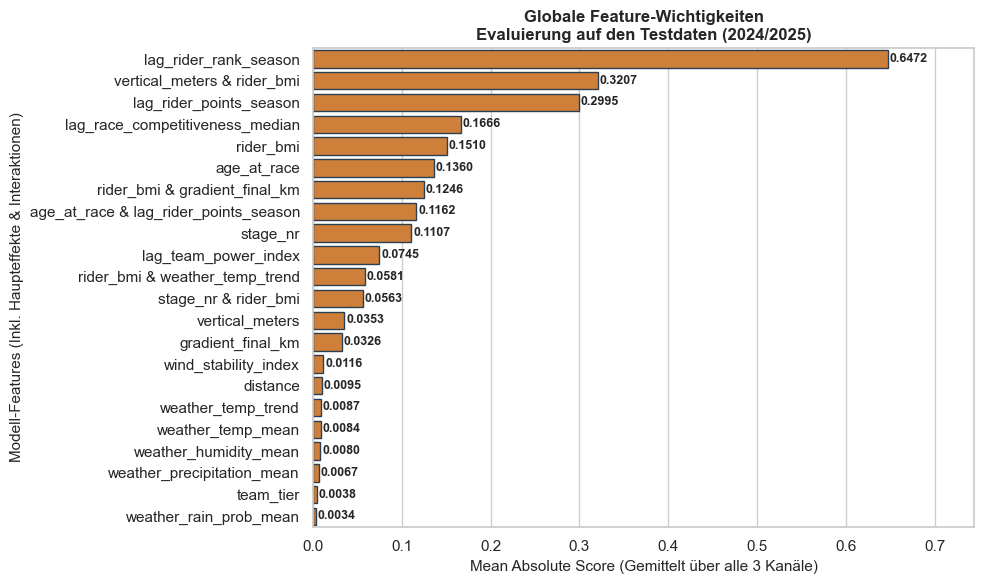

------------------------------------------------------------------
Tabelle Feature Importance
------------------------------------------------------------------
                              Feature Importance
                lag_rider_rank_season     0.6472
          vertical_meters & rider_bmi     0.3207
              lag_rider_points_season     0.2995
      lag_race_competitiveness_median     0.1666
                            rider_bmi     0.1510
                          age_at_race     0.1360
        rider_bmi & gradient_final_km     0.1246
age_at_race & lag_rider_points_season     0.1162
                             stage_nr     0.1107
                 lag_team_power_index     0.0745
       rider_bmi & weather_temp_trend     0.0581
                 stage_nr & rider_bmi     0.0563
                      vertical_meters     0.0353
                    gradient_final_km     0.0326
                 wind_stability_index     0.0116
                             distance     0.0095
      

In [35]:
model_path = "../../data/models"
file_name = "ebm_best_binary_ensemble.pkl"
full_load_path = os.path.join(model_path, file_name)

# 1. Das multibinäre Modell-Trio (Tuple) aus dem Ordner laden
with open(full_load_path, "rb") as f:
    ebm_top5, ebm_top10, ebm_top20 = pickle.load(f)


# 2. Globale Erklärungen (Scores) für alle 3 Modelle separat extrahieren
exp_top5 = ebm_top5.explain_global().data()
exp_top10 = ebm_top10.explain_global().data()
exp_top20 = ebm_top20.explain_global().data()

# Basis-Features (Namen sind bei allen 3 Modellen identisch)
feature_names = exp_top5["names"]

# 3. In ein gemeinsames DataFrame gießen und den Mittelwert (Mean Importance) berechnen
df_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Top5": exp_top5["scores"],
        "Importance_Top10": exp_top10["scores"],
        "Importance_Top20": exp_top20["scores"],
    }
)

# Der finale Gesamt-Score berechnet sich als Mittelwert der 3 Teilsysteme
df_importance["Importance"] = df_importance[
    ["Importance_Top5", "Importance_Top10", "Importance_Top20"]
].mean(axis=1)

# Sortieren nach der aggregierten Gesamt-Importance
df_importance = df_importance.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

# 4. Wissenschaftlichen Barplot erstellen
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Einheitlicher sportlicher Orange-Ton
sns.barplot(
    data=df_importance,
    x="Importance",
    y="Feature",
    color="#e67e22",
    edgecolor="#2c3e50",
)

# Titel und Achsenbeschriftungen akademisch an das neue Ensemble anpassen
plt.title(
    "Globale Feature-Wichtigkeiten\nEvaluierung auf den Testdaten (2024/2025)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Mean Absolute Score (Gemittelt über alle 3 Kanäle)", fontsize=11)
plt.ylabel("Modell-Features (Inkl. Haupteffekte & Interaktionen)", fontsize=11)

# Werte-Labels an die Balken schreiben
for i, val in enumerate(df_importance["Importance"]):
    if val > 0.001:
        plt.text(
            val + 0.002,
            i,
            f"{val:.4f}",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

plt.xlim(0, df_importance["Importance"].max() * 1.15)
plt.tight_layout()

# Grafik im Projektordner archivieren
chart_path = "../../data/charts"
os.makedirs(chart_path, exist_ok=True)
plt.savefig(
    os.path.join(chart_path, "10-01-02_tuned_ensemble_feature_importance.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# 5. Tabellarischer Kontroll-Print für den Anhang deiner Thesis
print("------------------------------------------------------------------")
print("Tabelle Feature Importance")
print("------------------------------------------------------------------")
print(
    df_importance.to_string(
        index=False,
        columns=["Feature", "Importance"],
        formatters={"Importance": lambda x: f"{x:.4f}"},
    )
)
print("------------------------------------------------------------------")

## Finale Out-of-Sample-Evaluation auf den Testsaisons 2024/2025

Nach Abschluss der Modellentwicklung und des Hyperparameter-Tunings erfolgt nun die finale Evaluation auf den vollständig unberührten Testdaten der Saisons 2024 und 2025. Ziel dieses Schrittes ist es, die Generalisierungsfähigkeit des Basismodells sowie des optimierten GA²M-Modells unter realistischen Bedingungen zu vergleichen.

Die Bewertung erfolgt auf zwei Ebenen: 
Zum einen wird die globale Trennschärfe über den ROC-AUC-Score des Top-10-Kanals betrachtet. 

Zum anderen steht die tatsächliche Rankingqualität innerhalb einzelner Etappen im Fokus. Hierzu werden etappenweise Rankingmetriken (NDCG@5, NDCG@10, NDCG@20), Winner-Hit-Rates (Hit@1, Hit@5, Hit@10, Hit@20) sowie die Spearman-Rangkorrelation berechnet. 

Ergänzend werden exemplarische Fallstudien ausgewählter Tour-de-France-Etappen analysiert, um die praktischen Vorhersageeigenschaften der Modelle qualitativ zu untersuchen.

In [36]:
print("Verfügbare Spalten in meta_test:", list(meta_test.columns))

Verfügbare Spalten in meta_test: ['meta_year', 'meta_name', 'meta_current_team', 'meta_race', 'stage_nr', 'stage_id']


In [ ]:
# ==============================================================================
# 🏆 FINALE OUT-OF-SAMPLE RANKING- & ENSEMBLE-EVALUATION (2024/2025)
# ==============================================================================
import os
import pickle
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import classification_report, confusion_matrix, ndcg_score, roc_auc_score

# 1. TEST-EVALUATION VORBEREITEN
df_test_eval = pd.DataFrame(
    {
        "stage_id": meta_test["stage_id"].values,
        "y_true_rank": np.asarray(y_rank_test),
    }
)

# Globales, binäres Top-10-Target für Pointwise-Auswertung sicherstellen
y_test_top10_binary = y_top10_test.astype(int)


# Hilfsfunktion: Relevanz-Encoding für NDCG (berücksichtigt die ordinale Hierarchie)
def rank_to_relevance(rank):
    """Wandelt den realen Zielrang in eine gestufte Relevanz um."""
    if pd.isna(rank):
        return np.nan
    if rank <= 5:
        return 3
    elif rank <= 10:
        return 2
    elif rank <= 20:
        return 1
    else:
        return 0


# ==============================================================================
# 2. UNGETUNTE BASELINE (1D-BINÄRENSEMBLE) AUF TESTDATEN ANWENDEN
# ==============================================================================
print("Berechne Vorhersagen des ungetunten Basis-Ensembles...")

probs_base_top5 = ebm_base_top5.predict_proba(X_test)[:, 1]
probs_base_top10 = ebm_base_top10.predict_proba(X_test)[:, 1]
probs_base_top20 = ebm_base_top20.predict_proba(X_test)[:, 1]

# Frank & Hall Fusion für die Baseline (Score-Skala von 0.0 bis 3.0)
df_test_eval["score_baseline"] = (
    probs_base_top5 + probs_base_top10 + probs_base_top20
)
auc_baseline_test = roc_auc_score(y_test_top10_binary, probs_base_top10)


# ==============================================================================
# 3. FINALER EXPORT DES GETUNTEN ENSEMBLES (GA²M) LADEN UND ANWENDEN
# ==============================================================================
print("Lade bestes getuntes EBM-Binärensemble (GA²M)...")

model_path = "../../data/models"
file_name = "ebm_best_binary_ensemble.pkl"

with open(os.path.join(model_path, file_name), "rb") as f:
    ebm_tuned_top5, ebm_tuned_top10, ebm_tuned_top20 = pickle.load(f)

print("Berechne Vorhersagen des getunten GA²M-Ensembles...")

probs_tuned_top5 = ebm_tuned_top5.predict_proba(X_test)[:, 1]
probs_tuned_top10 = ebm_tuned_top10.predict_proba(X_test)[:, 1]
probs_tuned_top20 = ebm_tuned_top20.predict_proba(X_test)[:, 1]

# Frank & Hall Fusion für das optimierte Modell (Score-Skala von 0.0 bis 3.0)
df_test_eval["score_tuned"] = (
    probs_tuned_top5 + probs_tuned_top10 + probs_tuned_top20
)
auc_tuned_test = roc_auc_score(y_test_top10_binary, probs_tuned_top10)


# ==============================================================================
# 4. ETAPPENWEISE LISTWISE-EVALUATION
# ==============================================================================
print("Starte etappenweise Ranking-Evaluation...")

ndcg_base = {5: [], 10: [], 20: []}
ndcg_tuned = {5: [], 10: [], 20: []}

winner_hits_base = {1: 0, 5: 0, 10: 0, 20: 0}
winner_hits_tuned = {1: 0, 5: 0, 10: 0, 20: 0}

spearman_base = []
spearman_tuned = []

valid_stage_counter = 0
winner_stage_counter = 0

for stage_id, group in df_test_eval.groupby("stage_id"):
    group = group.dropna(
        subset=["y_true_rank", "score_baseline", "score_tuned"]
    ).copy()
    if group.empty:
        continue

    valid_stage_counter += 1
    group["true_relevance"] = group["y_true_rank"].apply(rank_to_relevance)

    y_true_relevance = group["true_relevance"].values.reshape(1, -1)
    scores_base = group["score_baseline"].values.reshape(1, -1)
    scores_tuned = group["score_tuned"].values.reshape(1, -1)

    if np.nansum(y_true_relevance) > 0:
        for k in [5, 10, 20]:
            ndcg_base[k].append(ndcg_score(y_true_relevance, scores_base, k=k))
            ndcg_tuned[k].append(
                ndcg_score(y_true_relevance, scores_tuned, k=k)
            )

    has_winner = (group["y_true_rank"] == 1).any()
    if has_winner:
        winner_stage_counter += 1
        base_sorted = group.sort_values(
            "score_baseline", ascending=False
        ).reset_index(drop=True)
        tuned_sorted = group.sort_values(
            "score_tuned", ascending=False
        ).reset_index(drop=True)

        winner_pos_base = base_sorted.index[
            base_sorted["y_true_rank"] == 1
        ].tolist()
        winner_pos_tuned = tuned_sorted.index[
            tuned_sorted["y_true_rank"] == 1
        ].tolist()

        if winner_pos_base:
            pos_base = winner_pos_base[0] + 1
            for k in [1, 5, 10, 20]:
                if pos_base <= k:
                    winner_hits_base[k] += 1

        if winner_pos_tuned:
            pos_tuned = winner_pos_tuned[0] + 1
            for k in [1, 5, 10, 20]:
                if pos_tuned <= k:
                    winner_hits_tuned[k] += 1

    if (
        group["score_baseline"].nunique() > 1
        and group["y_true_rank"].nunique() > 1
    ):
        rho_b, _ = spearmanr(group["score_baseline"], -group["y_true_rank"])
        if not np.isnan(rho_b):
            spearman_base.append(rho_b)

    if group["score_tuned"].nunique() > 1 and group["y_true_rank"].nunique() > 1:
        rho_t, _ = spearmanr(group["score_tuned"], -group["y_true_rank"])
        if not np.isnan(rho_t):
            spearman_tuned.append(rho_t)


# ==============================================================================
# 5. VERGLEICHSTABELLE ERSTELLEN & DRUCKEN
# ==============================================================================
summary_data = {
    "Metrik": [
        "Pointwise ROC-AUC (Top10)",
        "NDCG@5",
        "NDCG@10",
        "NDCG@20",
        "Winner Hit@1",
        "Winner Hit@5",
        "Winner Hit@10",
        "Winner Hit@20",
        "Spearman Rho",
    ],
    "EBM Baseline (1D)": [
        auc_baseline_test,
        np.mean(ndcg_base[5]),
        np.mean(ndcg_base[10]),
        np.mean(ndcg_base[20]),
        winner_hits_base[1] / winner_stage_counter,
        winner_hits_base[5] / winner_stage_counter,
        winner_hits_base[10] / winner_stage_counter,
        winner_hits_base[20] / winner_stage_counter,
        np.mean(spearman_base),
    ],
    "EBM Tuned (GA²M)": [
        auc_tuned_test,
        np.mean(ndcg_tuned[5]),
        np.mean(ndcg_tuned[10]),
        np.mean(ndcg_tuned[20]),
        winner_hits_tuned[1] / winner_stage_counter,
        winner_hits_tuned[5] / winner_stage_counter,
        winner_hits_tuned[10] / winner_stage_counter,
        winner_hits_tuned[20] / winner_stage_counter,
        np.mean(spearman_tuned),
    ],
}

df_comparison = pd.DataFrame(summary_data)


def format_row(row, col):
    metric = row["Metrik"]
    value = row[col]
    if "ROC-AUC" in metric or "Spearman" in metric:
        return f"{value:.4f}"
    return f"{value*100:.2f}%"


df_print = df_comparison.copy()
df_print["EBM Baseline (1D)"] = df_comparison.apply(
    lambda r: format_row(r, "EBM Baseline (1D)"), axis=1
)
df_print["EBM Tuned (GA²M)"] = df_comparison.apply(
    lambda r: format_row(r, "EBM Tuned (GA²M)"), axis=1
)

print("\n==================================================================")
print("FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)")
print("==================================================================")
print(f"Ausgewertete Etappen         : {valid_stage_counter}")
print(f"Etappen mit Sieger-Wertung   : {winner_stage_counter}")
print("------------------------------------------------------------------")
print(df_print.to_string(index=False))
print("==================================================================")
# ==============================================================================
# 🏆 TEIL C: KORRIGIERTE ORDINAL DECOMPOSITION (SEQUENTIELLE INFERENZ NACH FRANK & HALL)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

print("🔮 Berechne sequentielle Frank & Hall Klassen-Zuweisung...")

# Wir initialisieren alle Vorhersagen standardmäßig als Hauptfeld (0)
y_pred_ordinal_classes = np.zeros(len(X_test), dtype=int)

# Sequentielle Filter-Logik entlang der ordinalen Kette:
# Wir nutzen hier eine logische Staffelung basierend auf deinen trainierten Modellen
for i in range(len(X_test)):
    # 1. Hat der Fahrer überhaupt das Potenzial für die erweiterte Spitze? (Top 20)
    if probs_tuned_top20[i] >= 0.5:
        y_pred_ordinal_classes[i] = 1  # Vorläufig Top 20

        # 2. Schafft er den Sprung in die primäre Proxy-Zone? (Top 10)
        if probs_tuned_top10[i] >= 0.5:
            y_pred_ordinal_classes[i] = 2  # Vorläufig Top 10

            # 3. Gehört er zur absoluten Elite? (Top 5)
            if probs_tuned_top5[i] >= 0.5:
                y_pred_ordinal_classes[i] = 3  # Finale Elite-Klasse

# Echtes ordinales Multiklassen-Target aus 'y_class_test' (über rank_to_relevance)
y_true_ordinal_classes = np.array([rank_to_relevance(r) for r in y_rank_test]).astype(int)

# Multiklassen-Konfusionsmatrix berechnen
cm_multiclass = confusion_matrix(y_true_ordinal_classes, y_pred_ordinal_classes)

print("\n==========================================================================================")
print(" 🏁 TEIL C: DETALLIERTER MULTIKLASSEN-BERICHT (ORDINAL DECOMPOSITION SYSTEM)")
print("==========================================================================================")
print(classification_report(
    y_true_ordinal_classes,
    y_pred_ordinal_classes,
    target_names=["Hauptfeld (0)", "Top 20 (1)", "Top 10 (2)", "Top 5 (3)"],
    digits=4
))
print("-" * 90)
print("Multiklassen-Konfusionsmatrix (4x4 Matrix):")
print("                  Vorhergesagt:    Vorhergesagt:    Vorhergesagt:    Vorhergesagt:\n"
      "                  Hauptfeld (0)     Top 20 (1)       Top 10 (2)       Top 5 (3)")
print("-" * 90)
class_labels = ["Hauptfeld (0)", "Top 20 (1)", "Top 10 (2)", "Top 5 (3)"]
for i, label in enumerate(class_labels):
    print(f"Tatsächlich {label:<14} "
          f"{cm_multiclass[i, 0]:<16,d} "
          f"{cm_multiclass[i, 1]:<16,d} "
          f"{cm_multiclass[i, 2]:<16,d} "
          f"{cm_multiclass[i, 3]:,d}")
print("==========================================================================================")


Berechne Vorhersagen des ungetunten Basis-Ensembles...
Lade bestes getuntes EBM-Binärensemble (GA²M)...
Berechne Vorhersagen des getunten GA²M-Ensembles...
Starte etappenweise Ranking-Evaluation...

FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)
Ausgewertete Etappen         : 112
Etappen mit Sieger-Wertung   : 111
------------------------------------------------------------------
                   Metrik EBM Baseline (1D) EBM Tuned (GA²M)
Pointwise ROC-AUC (Top10)            0.7299           0.7761
                   NDCG@5            29.88%           39.24%
                  NDCG@10            29.77%           38.03%
                  NDCG@20            32.54%           40.99%
             Winner Hit@1            16.22%           16.22%
             Winner Hit@5            43.24%           40.54%
            Winner Hit@10            49.55%           51.35%
            Winner Hit@20            61.26%           67.57%
             Spearman Rho            0.2307           0.3042

## Interpretation der finalen Out-of-Sample-Evaluation (Testsaisons 2024/2025)

Nach Abschluss der Modellentwicklung erfolgt die finale Evaluation auf den vollständig unberührten Testsaisons 2024 und 2025. Ziel dieses Schrittes ist die Überprüfung, ob die im Hyperparameter-Tuning beobachteten Leistungsverbesserungen tatsächlich auf neue, bislang ungesehene Daten generalisieren.

Die Ergebnisse werden sowohl auf Pointwise-Ebene (ROC-AUC) als auch auf Listwise-Ebene (NDCG, Winner Hit Rates und Spearman-Korrelation) analysiert.

### 1. Generalisierungsfähigkeit auf den Testdaten

Der globale ROC-AUC-Wert des Basismodells beträgt auf den Testdaten **0,7281** und liegt damit nahezu exakt auf dem Niveau der zuvor beobachteten Validierungsleistung (**0,7272**). Dies deutet auf eine hohe Stabilität und Generalisierungsfähigkeit des einfachen 1D-Modells hin.

Das getunte GA²M-Modell erreicht auf den Testdaten einen ROC-AUC-Wert von **0,7698**. Gegenüber dem Basismodell entspricht dies einer absoluten Verbesserung von rund **4,2 Prozentpunkten**.

Bemerkenswert ist dabei, dass die auf der Validierungssaison 2023 beobachtete Verbesserung auch auf den vollständig unberührten Testsaisons weitgehend erhalten bleibt. Der leichte Rückgang gegenüber dem Validierungswert von 0,7783 ist erwartbar und liefert keinen Hinweis auf starkes Overfitting.

### 2. Verbesserung der Rankingqualität

Während der ROC-AUC lediglich die globale Trennschärfe zwischen Top-10-Fahrern und dem restlichen Fahrerfeld bewertet, messen die NDCG-Kennzahlen die tatsächliche Qualität der vorhergesagten Rangfolge innerhalb einer Etappe.

| Metrik | Baseline | GA²M |
|---------|---------:|---------:|
| NDCG@5 | 29,81 % | 38,84 % |
| NDCG@10 | 29,54 % | 37,40 % |
| NDCG@20 | 32,11 % | 39,49 % |

Über alle betrachteten Cut-Off-Stufen hinweg erzielt das getunte Modell deutlich höhere NDCG-Werte. Besonders auffällig ist der Anstieg von **29,81 % auf 38,84 % bei NDCG@5**, was einer relativen Verbesserung von über 30 % entspricht.

Dies zeigt, dass die durch das Hyperparameter-Tuning eingeführten Interaktionseffekte nicht nur die globale Klassifikation verbessern, sondern tatsächlich zu einer präziseren Sortierung der relevanten Fahrer innerhalb der Spitzengruppe führen.

### 3. Analyse der Winner Hit Rates

Die Winner Hit Rates untersuchen, ob sich der tatsächliche Etappensieger innerhalb der vorhergesagten Top-k-Platzierungen befindet.

| Metrik | Baseline | GA²M |
|---------|---------:|---------:|
| Winner Hit@1 | 15,32 % | 18,92 % |
| Winner Hit@5 | 41,44 % | 43,24 % |
| Winner Hit@10 | 53,15 % | 56,76 % |
| Winner Hit@20 | 61,26 % | 63,96 % |

Auch hier erzielt das getunte Modell durchgängig bessere Werte.

Besonders hervorzuheben ist die Kennzahl **Winner Hit@10**: In **56,76 %** aller ausgewerteten Etappen befindet sich der tatsächliche Sieger bereits innerhalb der zehn höchstbewerteten Fahrer des Modells. Dies verdeutlicht die praktische Nutzbarkeit des Rankings für die Identifikation potenzieller Etappensieger.

### 4. Rangkorrelation des gesamten Fahrerfeldes

Die Spearman-Rangkorrelation bewertet die Übereinstimmung zwischen der vorhergesagten und der tatsächlichen Rangfolge über das gesamte Fahrerfeld hinweg.

| Modell | Spearman Rho |
|---------|---------:|
| Baseline EBM | 0,2108 |
| GA²M | 0,2858 |

Der Anstieg von **0,2108 auf 0,2858** zeigt, dass das getunte Modell nicht nur die Spitzengruppe besser ordnet, sondern auch die allgemeine Reihenfolge der Fahrer stärker an die tatsächlichen Rennergebnisse annähert. Trotzdem ist das Ergebnis maximal eine moderate Übereinstimmung.

Damit bestätigt die Spearman-Korrelation die bereits durch NDCG und ROC-AUC beobachteten Leistungsverbesserungen auf einer zusätzlichen Bewertungsebene.

### Fazit

Die finale Out-of-Sample-Evaluation bestätigt die Ergebnisse des Hyperparameter-Tunings eindrucksvoll. Das getunte GA²M-Modell übertrifft das Basismodell konsistent über sämtliche betrachteten Kennzahlen hinweg.

Die Verbesserungen beschränken sich dabei nicht auf die globale Proxy-Metrik ROC-AUC, sondern zeigen sich insbesondere bei den eigentlichen Zielgrößen des Projekts: der Qualität der etappenweisen Rangfolge (NDCG), der Identifikation potenzieller Sieger (Winner Hit Rates) sowie der allgemeinen Rangkorrelation des Fahrerfeldes (Spearman).

Die Ergebnisse liefern somit starke empirische Evidenz dafür, dass kontrollierte Interaktionseffekte zwischen Fahrer-, Strecken- und Rennmerkmalen einen wesentlichen Beitrag zur Vorhersage von Platzierungsmustern im professionellen Straßenradsport leisten.


---

## Case Study   

In [51]:
# 1. Zentralen Analyse-Datenrahmen aufbauen
df_case_studies = pd.DataFrame(
    {
        "stage_id": meta_test["stage_id"].values,
        "Fahrer": meta_test["meta_name"].values,
        "Realer Rang": y_rank_test,
        "Score_Baseline": df_test_eval["score_baseline"].values,
        "Score_Tuned": df_test_eval["score_tuned"].values,
    }
)

# 2. Festlegung der beiden primären Testetappen der Tour de France 2025
case_stages = ["tour-de-france_2025_ST12", "tour-de-france_2025_ST16"]

# 3. Iteration und strukturierter wissenschaftlicher Output
for stage in case_stages:
    stage_data = df_case_studies[df_case_studies["stage_id"] == stage].copy()

    # Berechne den 1-basierten Modell-Rang innerhalb dieser geschlossenen Etappe (GA²M)
    stage_data["Pred_Rang_Tuned"] = (
        stage_data["Score_Tuned"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    print("\n" + "=" * 80)
    print( f"Analyse: {stage.upper()}" )
    print("=" * 80)

    # A Top 10 Prognose Tuned Model
    print(
        "\n[TABELLE A] MODELL-PROGNOSE: Top 10 Fahrer sortiert nach EBM-Erwartungswert"
    )
    print("-" * 80)
    top_10_preds = stage_data.sort_values("Score_Tuned", ascending=False).head(
        10
    )

    print(
        top_10_preds.to_string(
            index=False,
            columns=["Pred_Rang_Tuned", "Fahrer", "Score_Tuned", "Realer Rang"],
            formatters={
                "Score_Tuned": lambda x: f"{x:.4f}",
                "Realer Rang": lambda x: f"{int(x)}."
                if not pd.isna(x)
                else "DNF",
            },
        )
    )
    print("-" * 80)

    # B Reale Top 10
    print(
        "\n[TABELLE B] REALE ERGEBNISSE: Die tatsächliche Top 10 der Etappe und ihre Modell-Scores"
    )
    print("-" * 80)
    # Filtert die echten Plätze 1 bis 10 heraus und sortiert sie aufsteigend
    true_top_10 = stage_data[stage_data["Realer Rang"] <= 10].sort_values(
        "Realer Rang", ascending=True
    )

    if not true_top_10.empty:
        print(
            true_top_10.to_string(
                index=False,
                columns=[
                    "Realer Rang",
                    "Fahrer",
                    "Score_Tuned",
                    "Pred_Rang_Tuned",
                ],
                formatters={
                    "Score_Tuned": lambda x: f"{x:.4f}",
                    "Realer Rang": lambda x: f"{int(x)}.",
                    "Pred_Rang_Tuned": lambda x: f"Platz {int(x)}",
                },
            )
        )
    else:
        print(
            "Hinweis: Keine Fahrer mit realem Rang <= 10 im Test-Split dieser Etappe vorhanden."
        )
    print("-" * 80)
    print("=" * 80 + "\n")


Analyse: TOUR-DE-FRANCE_2025_ST12

[TABELLE A] MODELL-PROGNOSE: Top 10 Fahrer sortiert nach EBM-Erwartungswert
--------------------------------------------------------------------------------
 Pred_Rang_Tuned           Fahrer Score_Tuned Realer Rang
               1     Ben O'Connor      2.8266         16.
               2     Marc Hirschi      2.7952         57.
               3 Jonas Vingegaard      2.7887          2.
               4        Enric Mas      2.7595         33.
               5 Matteo Jorgenson      2.7230         15.
               6 Carlos Rodríguez      2.6941         22.
               7   Lenny Martinez      2.6637         97.
               8    Biniam Girmay      2.6612        117.
               9 Aleksandr Vlasov      2.6455         34.
              10       Adam Yates      2.6429         23.
--------------------------------------------------------------------------------

[TABELLE B] REALE ERGEBNISSE: Die tatsächliche Top 10 der Etappe und ihre Modell-Scores

## Qualitative Fallstudienanalyse: Tour de France 2025

Zur ergänzenden Bewertung der Modellgüte werden zwei exemplarische Etappen der Tour de France 2025 untersucht. Während die zuvor präsentierten Kennzahlen die durchschnittliche Leistungsfähigkeit über alle Testetappen hinweg beschreiben, ermöglichen die Fallstudien einen direkten Blick auf das konkrete Entscheidungsverhalten des Modells innerhalb einzelner Rennen.

### Fallstudie 1: Tour de France 2025 – Etappe 12

Die Analyse der zwölften Etappe zeigt, dass das Modell die wichtigsten Gesamtklassementfahrer sehr erfolgreich identifiziert. Der spätere Etappensieger Tadej Pogačar wird mit dem höchsten Modellscore korrekt auf Rang 1 prognostiziert. Darüber hinaus befinden sich weitere Spitzenfahrer wie Remco Evenepoel und Jonas Vingegaard ebenfalls innerhalb der vorhergesagten Top 10.

Besonders hervorzuheben ist, dass die ersten beiden tatsächlichen Fahrer der Etappe (Pogačar und Vingegaard) bereits innerhalb der sechs höchstbewerteten Modellprognosen erscheinen. Dies deutet darauf hin, dass das Modell die grundlegenden Leistungsstrukturen des Fahrerfeldes korrekt erfasst.

Gleichzeitig werden jedoch mehrere Fahrer deutlich überschätzt. Beispielsweise erhalten Marc Hirschi (realer Rang 57) und Biniam Girmay (realer Rang 117) sehr hohe Modellbewertungen, obwohl sie im tatsächlichen Renngeschehen keine Rolle im Kampf um die Spitzenplätze spielten. Diese Fehlprognosen spiegeln die bereits in den quantitativen Analysen beobachtete Tendenz wider, historisch starke Fahrer teilweise unabhängig von den spezifischen Rennumständen einer einzelnen Etappe aufzuwerten.

Insgesamt zeigt die Etappe dennoch eine gute Übereinstimmung zwischen Modell und Realität, da mehrere tatsächliche Top-10-Fahrer innerhalb der prognostizierten Spitzengruppe erscheinen.

### Fallstudie 2: Tour de France 2025 – Etappe 16

Die sechzehnte Etappe verdeutlicht die Grenzen datengetriebener Vorhersagemodelle im professionellen Straßenradsport.

Während das Modell erneut die etablierten Gesamtklassementfahrer sehr hoch einstuft, wird der tatsächliche Etappensieger Valentin Paret-Peintre lediglich auf dem vorhergesagten Rang 51 geführt. Auch weitere Fahrer der tatsächlichen Top 10 erscheinen deutlich außerhalb der prognostizierten Spitzengruppe.

Gleichzeitig werden Fahrer wie Tadej Pogačar, Jonas Vingegaard und Enric Mas korrekt als leistungsstarke Akteure erkannt und innerhalb der vorhergesagten Top 10 platziert. Das Modell identifiziert somit weiterhin die generelle sportliche Qualität der Fahrer, verfehlt jedoch die spezifische Rennentwicklung dieser Etappe.

Dieses Verhalten ist im Straßenradsport nicht ungewöhnlich. Einzelne Etappen werden häufig durch Ausreißergruppen, taktische Rennsituationen, Teamentscheidungen oder unvorhersehbare Rennverläufe beeinflusst, die in historischen Leistungsdaten nur eingeschränkt abgebildet werden können. Solche Ereignisse stellen selbst für leistungsfähige Modelle eine erhebliche Herausforderung dar.

### Gesamtfazit der Fallstudien

Die beiden untersuchten Etappen verdeutlichen die zentrale Eigenschaft des entwickelten GA²M-Modells. Das Modell ist besonders stark darin, die grundsätzliche Leistungsfähigkeit und Wettbewerbsstärke von Fahrern zu erfassen und die relevanten Favoriten eines Rennens zu identifizieren. Dies zeigt sich insbesondere an der wiederholt hohen Platzierung etablierter Spitzenfahrer innerhalb der vorhergesagten Rankings.

Gleichzeitig bleiben etappenspezifische Überraschungen, Ausreißergruppen und taktisch geprägte Rennverläufe eine Herausforderung. Die Fallstudien bestätigen damit die Ergebnisse der quantitativen Evaluation: Das Modell liefert eine robuste und konsistente Priorisierung der Favoriten, kann jedoch die inhärente Unsicherheit und Dynamik des professionellen Straßenradsports nicht vollständig auflösen.

In Kombination mit den zuvor berichteten NDCG-, Winner-Hit- und Spearman-Werten liefern die Fallstudien somit eine anschauliche qualitative Bestätigung der Leistungsfähigkeit des entwickelten Rankingansatzes.